# 4_inter_intra_classification.ipynb

This notebook compares two IO-author classification settings with paired target-campaign splits:

1. **Intra-campaign** - train on a labeled fraction of the target campaign and evaluate on its remaining accounts.
2. **Inter-campaign** - train on every non-target account plus the same labeled target fraction, then evaluate on the same remaining target accounts.

For each target campaign and training fraction, five deterministic stratified shuffle splits are evaluated with ROC-AUC, PR-AUC, F1, recall, and precision.

**Pipeline position:** Runs after the classification sweep in `step_3_key_authors_graph`.

# Imports

In [1]:
from __future__ import annotations

# File system
from pathlib import Path
import gc
import json
import time

# Data
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# sklearn and models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer, precision_score, recall_score
from sklearn.model_selection import StratifiedShuffleSplit, cross_validate
from xgboost import XGBClassifier

# Utilities
from tqdm.auto import tqdm

# Parameters

Papermill will inject values into the tagged cell below.
* `CAMPAIGNS` lists the campaigns to run the sweep over. 
* The `topic_method`, `edge_types`, `top_percentage`, and `graph_filtering_setting` values are used to build each campaign's exact `accounts_graph...indicators.parquet` file path. `top_percentage` uses the 1-100 scale, where 1 means 1%.

In [2]:
# Campaigns - each must have a completed step-3 sweep run at the standard location
CAMPAIGNS = ["Iran_1", "UAE", "Venezuela", "China_1", "Cuba", "Russia_1"]

output_dir = "../results/Labeled_Datasets/step_4_inter_intra_classification"

# Sweep configuration - used to build each campaign's exact indicator file path
graph_filtering_setting = "all_authors"  # "all_authors" or "graph_authors"
topic_method = "BERTopic_topic_256"  # BERTopic_topic_128, K_Means_topic_124
edge_types = "similarity+text_similarity+interactions"
top_percentage = 100

# Fractions of labeled target-campaign accounts used for training.
FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 0.80]
N_SPLITS = 5

MODELS = ["xgboost", "random_forest"] # "logistic_regression"
RANDOM_STATE = 42

# Configuration

In [3]:
def validate_percentage(value: float | int, value_name: str) -> float:
    """Return a percentage after validating the shared 1-100 scale.

    Args:
        value: Percentage value from 1 through 100.
        value_name: Parameter name used in an error message.

    Returns:
        Validated percentage as a float.

    Raises:
        ValueError: If value is outside the inclusive range [1, 100].
    """
    percentage = float(value)
    if not 1 <= percentage <= 100:
        raise ValueError(
            f"{value_name} must be in [1, 100], where 1 means 1%; "
            f"got {value}."
        )
    return percentage

In [4]:
top_percentage = validate_percentage(top_percentage, "top_percentage")
CONFIG_TAG = (
    f"{graph_filtering_setting}_{topic_method}_{edge_types}"
    f"_top_percentage_{top_percentage:g}"
)


def build_indicator_path(campaign: str, graph_filtering_setting: str) -> Path:
    """Build a campaign's step-3 indicator file path from the sweep config.

    Args:
        campaign: Campaign name (matches its results directory name).
        graph_filtering_setting: Graph filtering setting (e.g., "all_authors" or "graph_authors").

    Returns:
        Path to the expected `classification_sweep_indicators` parquet file.
    """
    base_dir = Path(
        f"../results/Labeled_Datasets/{campaign}/{campaign}_part_all"
        f"/step_3_key_authors_graph/"
        # f"topic_col_{topic_method}_top_percentage_{top_percentage:g}/classification_sweep_indicators/"
        f"classification_sweep/classification_sweep_indicators/"
        f"{graph_filtering_setting}"
    )
    sweep_filename = (
        f"accounts_graph_{topic_method}_{edge_types}"
        f"_top_percentage_{top_percentage:g}_per_topic"
        f"_topic_col_{topic_method}_undirected_indicators.parquet"
    )
    return base_dir / sweep_filename


campaign_base_dirs = {campaign: build_indicator_path(campaign, graph_filtering_setting) for campaign in CAMPAIGNS}

print("Campaigns' paths:")
for campaign, path in campaign_base_dirs.items():
    print(f"  {campaign}: {path}")


for campaign, path in campaign_base_dirs.items():
    if not path.exists():
        raise FileNotFoundError(
            f"No data found for '{campaign}' at: {path}\n"
            f"Has the pipeline completed step 3 for this campaign?"
        )

Campaigns' paths:
  Iran_1: ../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  UAE: ../results/Labeled_Datasets/UAE/UAE_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  Venezuela: ../results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  China_1: ../results/Labeled_Datasets/Chin

# Logs

In [5]:
campaign_group_name = "_".join(
    sorted(campaign.lower().replace(" ", "_") for campaign in CAMPAIGNS)
)
output_path = Path(output_dir).expanduser() / campaign_group_name
output_path.mkdir(parents=True, exist_ok=True)
REPORT_PATH = output_path / "progress_report.txt"


def write_report(msg: str) -> None:
    """Write a timestamped message to stdout and the progress report.

    Args:
        msg: Message to write.
    """
    line = f"{time.strftime('%Y-%m-%d %H:%M:%S')} | {msg}"
    print(line)
    with open(REPORT_PATH, "a", encoding="utf-8") as report_file:
        report_file.write(line + "\n")


write_report(f"Campaign paths: {campaign_base_dirs}")
write_report(f"Output path: {output_path}")

2026-08-18 12:09:51 | Campaign paths: {'Iran_1': PosixPath('../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet'), 'UAE': PosixPath('../results/Labeled_Datasets/UAE/UAE_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet'), 'Venezuela': PosixPath('../results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_in

# Classification

In [6]:
def get_classifier(model_name: str, random_state: int = RANDOM_STATE, **kwargs):
    """Return a sklearn-compatible classifier by name.

    Args:
        model_name: One of "xgboost"/"xgb", "random_forest"/"rf",
            "logistic_regression"/"lr".
        random_state: Random seed forwarded to the classifier constructor.
        **kwargs: Additional keyword arguments passed to the constructor.

    Returns:
        An untrained sklearn-compatible classifier instance.

    Raises:
        ValueError: If model_name is not recognised.
    """
    name = model_name.lower()
    if name in ("xgboost", "xgb"):
        return XGBClassifier(
            random_state=random_state,
            eval_metric="logloss",
            n_jobs=1,
            **kwargs,
        )
    if name in ("random_forest", "rf"):
        return RandomForestClassifier(
            random_state=random_state, n_jobs=1, **kwargs
        )
    if name in ("logistic_regression", "lr"):
        return LogisticRegression(
            random_state=random_state,
            solver="liblinear",
            max_iter=1000,
            n_jobs=1,
            **kwargs,
        )
    raise ValueError(
        f"Unsupported model_name: '{model_name}'. "
        "Supported: xgboost/xgb, random_forest/rf, logistic_regression/lr."
    )

# Data Loading

Each campaign path points to an author-level node-indicator parquet file. Labels are read from `io_drive_label` when present, or from step 3's `io_author_analysis/io_authors_by_post_ratio.json`.

`load_country_data` adds the source campaign in `campaign_name`. `load_multiple_campaigns` concatenates campaigns while preserving that column and unique prefixed author IDs.

In [7]:
def load_country_data(
    campaign_name: str,
    indicator_path: str | Path,
    prefix_ids: bool = True,
    normalize: bool = True,
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, set[str]]:
    """Load one campaign's node indicators and IO-author labels.

    Args:
        campaign_name: Campaign label added to every returned row.
        indicator_path: Path to the campaign indicator parquet file.
        prefix_ids: Whether to prefix author IDs with the campaign name.
        normalize: Whether to min-max normalize numeric features within the
            complete campaign. Constant columns are set to zero.
        feature_columns: Optional ordered numeric feature list.

    Returns:
        A feature DataFrame with a ``campaign_name`` column and the set of IO
        author IDs using the same optional campaign prefix.

    Raises:
        FileNotFoundError: If the indicator file does not exist.
        ValueError: If labels or requested features are unavailable.
    """
    campaign_name = campaign_name.strip()
    path = Path(indicator_path).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"No indicator file for '{campaign_name}' at: {path}")

    df_features = pd.read_parquet(path)
    if "io_drive_label" in df_features.columns:
        io_labels = pd.to_numeric(df_features["io_drive_label"], errors="coerce")
        io_set = set(df_features.index[io_labels.eq(1)].astype(str))
    else:
        step_3_dir = path.parents[3]
        label_paths = sorted(
            step_3_dir.glob(
                "topic_col_*/io_author_analysis/io_authors_by_post_ratio.json"
            )
        )
        if not label_paths:
            raise ValueError(
                f"'{path}' has no 'io_drive_label' column and no "
                "io_author_analysis/io_authors_by_post_ratio.json was found "
                f"below '{step_3_dir}'."
            )
        with open(label_paths[0], encoding="utf-8") as label_file:
            io_set = set(map(str, json.load(label_file)))
        write_report(
            f"'{campaign_name}' has no embedded io_drive_label; "
            f"loaded labels from: {label_paths[0]}"
        )

    df_features = df_features.drop(
        columns=[
            "io_drive_label",
            "louvain_community",
            "top_topic",
            "boost_score",
        ],
        errors="ignore",
    ).select_dtypes(include="number")

    if feature_columns is not None:
        missing_columns = sorted(set(feature_columns) - set(df_features.columns))
        if missing_columns:
            raise ValueError(
                f"'{campaign_name}' is missing shared features: {missing_columns}"
            )
        df_features = df_features[feature_columns].copy()

    if normalize:
        numeric_columns = df_features.columns
        column_min = df_features[numeric_columns].min()
        column_range = (
            df_features[numeric_columns].max() - column_min
        ).replace(0, 1)
        df_features[numeric_columns] = (
            df_features[numeric_columns] - column_min
        ) / column_range

    if prefix_ids:
        df_features.index = campaign_name + "_" + df_features.index.astype(str)
        io_set = {f"{campaign_name}_{author_id}" for author_id in io_set}

    df_features["campaign_name"] = campaign_name
    n_io_in_graph = len(set(df_features.index.astype(str)) & io_set)
    write_report(
        f"Loaded '{campaign_name}' ({path}) | {len(df_features):,} authors "
        f"| {len(io_set):,} IO authors (dataset) "
        f"| {n_io_in_graph:,} IO in graph"
    )
    return df_features, io_set


def load_multiple_campaigns(
    campaign_paths: dict[str, Path],
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, set[str]]:
    """Load and concatenate multiple campaign feature tables.

    Args:
        campaign_paths: Campaign names mapped to indicator parquet paths.
        feature_columns: Optional ordered numeric feature list.

    Returns:
        Combined feature DataFrame and union of campaign-prefixed IO authors.
    """
    frames = []
    combined_io = set()
    for campaign_name, path in campaign_paths.items():
        campaign_df, io_set = load_country_data(
            campaign_name,
            path,
            prefix_ids=True,
            feature_columns=feature_columns,
        )
        frames.append(campaign_df)
        combined_io.update(io_set)
    return pd.concat(frames, axis=0), combined_io

In [8]:
# Use the same feature schema for every train/test campaign combination.


def get_common_numeric_feature_columns(
    campaign_paths: dict[str, Path],
) -> list[str]:
    """Return numeric model features present in every campaign.

    Args:
        campaign_paths: Campaign names mapped to indicator parquet paths.

    Returns:
        Numeric feature names shared by every campaign, in source order.
    """
    excluded_columns = {
        "io_drive_label",
        "louvain_community",
        "top_topic",
        "boost_score",
    }
    numeric_columns_by_campaign = {}
    for campaign_name, path in campaign_paths.items():
        campaign_df = pd.read_parquet(path)
        numeric_columns_by_campaign[campaign_name] = [
            column
            for column in campaign_df.select_dtypes(include="number").columns
            if column not in excluded_columns
        ]

    first_campaign = next(iter(campaign_paths))
    common_columns = set.intersection(
        *(set(columns) for columns in numeric_columns_by_campaign.values())
    )
    ordered_columns = [
        column
        for column in numeric_columns_by_campaign[first_campaign]
        if column in common_columns
    ]
    if not ordered_columns:
        raise ValueError("The selected campaigns have no numeric features in common.")
    return ordered_columns


FEATURE_COLUMNS_USED = get_common_numeric_feature_columns(campaign_base_dirs)
write_report(
    f"Common feature columns used ({len(FEATURE_COLUMNS_USED)}): "
    f"{FEATURE_COLUMNS_USED}"
)
gc.collect()

2026-08-18 12:09:52 | Common feature columns used (10): ['degree_centrality', 'harmonic_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'pagerank', 'core_number', 'clustering', 'key_score_sum', 'key_score_dominance', 'posting_dominance']


20

# Cross-Validation

In [9]:
SCORING = {
    "auc_roc": "roc_auc",
    "auc_pr": "average_precision",
    "f1": make_scorer(f1_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
}
METRIC_COLUMNS = list(SCORING)


def build_paired_cv_splits(
    y_target: np.ndarray,
    n_other_authors: int,
    train_fraction: float,
    n_splits: int = N_SPLITS,
) -> tuple[list[tuple[np.ndarray, np.ndarray]], list[tuple[np.ndarray, np.ndarray]]]:
    """Create paired within- and cross-campaign splits.

    Args:
        y_target: Binary target-campaign labels.
        n_other_authors: Number of non-target accounts.
        train_fraction: Fraction of target accounts used for training.
        n_splits: Number of repeated stratified partitions.

    Returns:
        Intra and inter splits with identical target test indices.
    """
    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_fraction,
        random_state=RANDOM_STATE,
    )
    intra_splits = list(splitter.split(np.zeros(len(y_target)), y_target))
    other_indices = np.arange(
        len(y_target), len(y_target) + n_other_authors
    )
    inter_splits = [
        (np.concatenate([other_indices, train]), test)
        for train, test in intra_splits
    ]
    for (train, test), (inter_train, inter_test) in zip(
        intra_splits, inter_splits
    ):
        assert np.array_equal(test, inter_test) and test.max() < len(y_target)
        assert not np.intersect1d(train, test).size
        assert np.array_equal(inter_train[:n_other_authors], other_indices)
        assert set(y_target[train]) == set(y_target[test]) == {0, 1}
        assert abs(len(train) / len(y_target) - train_fraction) <= 1 / len(y_target)
    return intra_splits, inter_splits


def cross_validate_experiment(
    features: pd.DataFrame,
    labels: np.ndarray,
    cv_splits: list[tuple[np.ndarray, np.ndarray]],
    context: dict,
) -> pd.DataFrame:
    """Evaluate one experiment and return one row per split.

    Args:
        features: Numeric model features.
        labels: Binary labels aligned with features.
        cv_splits: Explicit train/test index pairs.
        context: Metadata shared by the returned rows.

    Returns:
        Split-level scores and metadata.
    """
    if "campaign_name" in features:
        raise ValueError("campaign_name must not be a model feature")

    scores = cross_validate(
        get_classifier(context["model"]),
        features,
        labels,
        cv=cv_splits,
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise",
    )
    return pd.DataFrame([
        {
            **context,
            "split": split_number,
            "train_size": len(train),
            "test_size": len(test),
            "random_state": RANDOM_STATE,
            **{
                metric: float(scores[f"test_{metric}"][split_number - 1])
                for metric in METRIC_COLUMNS
            },
        }
        for split_number, (train, test) in enumerate(cv_splits, start=1)
    ])


# Experiment Sweep

For each target campaign and labeled training fraction, one set of five stratified target partitions is reused by both experiment types. Intra uses only the target training partition; inter adds every account from the other campaigns. Both evaluate on the identical remaining target accounts.

In [10]:
def run_experiment_sweep(
    campaigns: list[str],
    fractions: list[float],
    models: list[str],
    n_splits: int = N_SPLITS,
) -> pd.DataFrame:
    """Run paired within- and cross-campaign evaluations.

    Intra trains on a target fraction. Inter adds all non-target accounts to
    the same target fraction and evaluates on the same target test accounts.

    Args:
        campaigns: Ordered target campaigns.
        fractions: Labeled target fractions used for training.
        models: Classifier names accepted by get_classifier.
        n_splits: Repeated stratified partitions per fraction.

    Returns:
        One result row per model, strategy, and split.
    """
    unknown = sorted(set(campaigns) - set(campaign_base_dirs))
    if len(campaigns) < 2 or unknown:
        raise ValueError(
            f"At least two known campaigns are required; unknown={unknown}"
        )

    all_features, io_authors = load_multiple_campaigns(
        {campaign: campaign_base_dirs[campaign] for campaign in campaigns},
        feature_columns=FEATURE_COLUMNS_USED,
    )
    campaign_names = all_features["campaign_name"].to_numpy()
    all_labels = all_features.index.astype(str).isin(io_authors).astype(np.int8)
    result_frames = []

    for target_campaign in tqdm(campaigns, desc="Target campaigns"):
        target_mask = campaign_names == target_campaign
        target_features = all_features.loc[
            target_mask, FEATURE_COLUMNS_USED
        ].reset_index(drop=True)
        other_features = all_features.loc[
            ~target_mask, FEATURE_COLUMNS_USED
        ].reset_index(drop=True)
        y_target = np.asarray(all_labels[target_mask], dtype=np.int8)
        y_other = np.asarray(all_labels[~target_mask], dtype=np.int8)

        inter_features = pd.concat(
            [target_features, other_features],
            ignore_index=True,
        )
        inter_labels = np.concatenate([y_target, y_other])
        other_campaigns = [
            campaign for campaign in campaigns if campaign != target_campaign
        ]
        write_report(
            f"Target: {target_campaign} | {len(target_features):,} target authors | "
            f"{len(other_features):,} other authors"
        )

        for fraction in tqdm(
            fractions,
            desc=f"{target_campaign} fractions",
            leave=False,
        ):
            intra_splits, inter_splits = build_paired_cv_splits(
                y_target,
                len(other_features),
                fraction,
                n_splits,
            )
            inter_training = (
                f"{','.join(other_campaigns)} + "
                f"{target_campaign} ({fraction:.0%})"
            )

            for model_name in models:
                write_report(f"Model: {model_name} | {fraction:.0%} fraction | {n_splits} splits")
                shared = {
                    "target_campaign": target_campaign,
                    "graph_filtering_setting": graph_filtering_setting,
                    "train_fraction": fraction,
                    "model": model_name,
                }
                result_frames.extend([
                    cross_validate_experiment(
                        target_features,
                        y_target,
                        intra_splits,
                        {
                            "training_campaign": target_campaign,
                            **shared,
                            "experiment_type": "intra",
                        },
                    ),
                    cross_validate_experiment(
                        inter_features,
                        inter_labels,
                        inter_splits,
                        {
                            "training_campaign": inter_training,
                            **shared,
                            "experiment_type": "inter",
                        },
                    ),
                ])

    results = pd.concat(result_frames, ignore_index=True)
    expected = len(campaigns) * len(fractions) * len(models) * 2 * n_splits
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected:,} rows, got {len(results):,}")
    return results


# Execution

In [11]:
write_report("Starting paired intra/inter IO classification sweep.")
write_report(f"Campaigns: {CAMPAIGNS}")
write_report(f"Target training fractions: {FRACTIONS}")
write_report(f"Models: {MODELS}")
write_report(f"Stratified splits: {N_SPLITS}")
write_report(f"Random state: {RANDOM_STATE}")
write_report(f"Graph filter: {graph_filtering_setting}")
write_report(f"Key-author selection percentage: {top_percentage:g}%")
write_report(f"Output dir: {output_path}")

results_df = run_experiment_sweep(
    campaigns=CAMPAIGNS,
    fractions=FRACTIONS,
    models=MODELS,
    n_splits=N_SPLITS,
)

if results_df.empty:
    write_report(
        "WARNING: No results collected. Ensure every campaign has completed step 3."
    )
else:
    write_report(f"Sweep complete - {len(results_df):,} result rows collected.")
    display(results_df.head(12))

2026-08-18 12:09:52 | Starting paired intra/inter IO classification sweep.
2026-08-18 12:09:52 | Campaigns: ['Iran_1', 'UAE', 'Venezuela', 'China_1', 'Cuba', 'Russia_1']
2026-08-18 12:09:52 | Target training fractions: [0.01, 0.05, 0.1, 0.25, 0.5, 0.8]
2026-08-18 12:09:52 | Models: ['xgboost', 'random_forest']
2026-08-18 12:09:52 | Stratified splits: 5
2026-08-18 12:09:52 | Random state: 42
2026-08-18 12:09:52 | Graph filter: all_authors
2026-08-18 12:09:52 | Key-author selection percentage: 100%
2026-08-18 12:09:52 | Output dir: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela
2026-08-18 12:09:52 | 'Iran_1' has no embedded io_drive_label; loaded labels from: ../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/io_author_analysis/io_authors_by_post_ratio.json
2026-08-18 12:09:52 | Loaded 'Iran_1' (../results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_au

Target campaigns:   0%|          | 0/6 [00:00<?, ?it/s]

2026-08-18 12:09:52 | Target: Iran_1 | 5,675 target authors | 132,570 other authors


Iran_1 fractions:   0%|          | 0/6 [00:00<?, ?it/s]

2026-08-18 12:09:52 | Model: xgboost | 1% fraction | 5 splits
2026-08-18 12:09:57 | Model: random_forest | 1% fraction | 5 splits
2026-08-18 12:10:46 | Model: xgboost | 5% fraction | 5 splits
2026-08-18 12:10:47 | Model: random_forest | 5% fraction | 5 splits
2026-08-18 12:11:26 | Model: xgboost | 10% fraction | 5 splits
2026-08-18 12:11:27 | Model: random_forest | 10% fraction | 5 splits
2026-08-18 12:12:06 | Model: xgboost | 25% fraction | 5 splits
2026-08-18 12:12:07 | Model: random_forest | 25% fraction | 5 splits
2026-08-18 12:12:48 | Model: xgboost | 50% fraction | 5 splits
2026-08-18 12:12:50 | Model: random_forest | 50% fraction | 5 splits
2026-08-18 12:13:30 | Model: xgboost | 80% fraction | 5 splits
2026-08-18 12:13:31 | Model: random_forest | 80% fraction | 5 splits
2026-08-18 12:14:15 | Target: UAE | 14,202 target authors | 124,043 other authors


...

Cuba fractions:   0%|          | 0/6 [00:00<?, ?it/s]

2026-08-18 12:25:53 | Model: xgboost | 1% fraction | 5 splits
2026-08-18 12:25:55 | Model: random_forest | 1% fraction | 5 splits
2026-08-18 12:26:26 | Model: xgboost | 5% fraction | 5 splits
2026-08-18 12:26:27 | Model: random_forest | 5% fraction | 5 splits
2026-08-18 12:26:59 | Model: xgboost | 10% fraction | 5 splits
2026-08-18 12:27:00 | Model: random_forest | 10% fraction | 5 splits
2026-08-18 12:27:32 | Model: xgboost | 25% fraction | 5 splits
2026-08-18 12:27:34 | Model: random_forest | 25% fraction | 5 splits
2026-08-18 12:28:08 | Model: xgboost | 50% fraction | 5 splits
2026-08-18 12:28:09 | Model: random_forest | 50% fraction | 5 splits
2026-08-18 12:28:46 | Model: xgboost | 80% fraction | 5 splits
2026-08-18 12:28:47 | Model: random_forest | 80% fraction | 5 splits
2026-08-18 12:29:29 | Target: Russia_1 | 34,592 target authors | 103,653 other authors


Russia_1 fractions:   0%|          | 0/6 [00:00<?, ?it/s]

2026-08-18 12:29:29 | Model: xgboost | 1% fraction | 5 splits
2026-08-18 12:29:30 | Model: random_forest | 1% fraction | 5 splits
2026-08-18 12:30:03 | Model: xgboost | 5% fraction | 5 splits
2026-08-18 12:30:05 | Model: random_forest | 5% fraction | 5 splits
2026-08-18 12:30:38 | Model: xgboost | 10% fraction | 5 splits
2026-08-18 12:30:40 | Model: random_forest | 10% fraction | 5 splits
2026-08-18 12:31:13 | Model: xgboost | 25% fraction | 5 splits
2026-08-18 12:31:15 | Model: random_forest | 25% fraction | 5 splits
2026-08-18 12:31:50 | Model: xgboost | 50% fraction | 5 splits
2026-08-18 12:31:51 | Model: random_forest | 50% fraction | 5 splits
2026-08-18 12:32:30 | Model: xgboost | 80% fraction | 5 splits
2026-08-18 12:32:32 | Model: random_forest | 80% fraction | 5 splits
2026-08-18 12:33:15 | Sweep complete - 720 result rows collected.


,training_campaign,target_campaign,graph_filtering_setting,train_fraction,model,experiment_type,split,train_size,test_size,random_state,auc_roc,auc_pr,f1,recall,precision
0,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,1,56,5619,42,0.964579,0.860658,0.910207,0.908116,0.912308
1,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,2,56,5619,42,0.963593,0.890475,0.796688,0.663093,0.997696
2,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,3,56,5619,42,0.967569,0.876754,0.852890,0.745789,0.995910
3,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,4,56,5619,42,0.967226,0.932320,0.934747,0.877489,1.000000
4,Iran_1,Iran_1,all_authors,0.01,xgboost,intra,5,56,5619,42,0.965387,0.860919,0.832143,0.713629,0.997859
5,"UAE,Venezuela,China_1,Cuba,Russia_1 + Iran_1 (1%)",Iran_1,all_authors,0.01,xgboost,inter,1,132626,5619,42,0.980673,0.918258,0.841667,0.773354,0.923218
6,"UAE,Venezuela,China_1,Cuba,Russia_1 + Iran_1 (1%)",Iran_1,all_authors,0.01,xgboost,inter,2,132626,5619,42,0.981882,0.927891,0.853333,0.784074,0.936015
7,"UAE,Venezuela,China_1,Cuba,Russia_1 + Iran_1 (1%)",Iran_1,all_authors,0.01,xgboost,inter,3,132626,5619,42,0.977424,0.911109,0.818884,0.730475,0.931641
8,"UAE,Venezuela,China_1,Cuba,Russia_1 + Iran_1 (1%)",Iran_1,all_authors,0.01,xgboost,inter,4,132626,5619,42,0.976310,0.910116,0.825043,0.736600,0.937622
9,"UAE,Venezuela,China_1,Cuba,Russia_1 + Iran_1 (1%)",Iran_1,all_authors,0.01,xgboost,inter,5,132626,5619,42,0.977032,0.909755,0.834315,0.759571,0.925373


# Save Results

In [12]:
if not results_df.empty:
    csv_path = output_path / f"experiment_results_{CONFIG_TAG}.csv"
    results_df.to_csv(csv_path, index=False)
    write_report(f"Split-level results saved to: {csv_path}")
    display(results_df.describe())

    agg_path = output_path / f"experiment_results_{CONFIG_TAG}_aggregated.csv"
    results_agg = (
        results_df
        .groupby(
            ["target_campaign", "experiment_type", "model", "train_fraction"]
        )
        .agg(
            auc_roc_mean=("auc_roc", "mean"),
            auc_roc_std=("auc_roc", "std"),
            auc_pr_mean=("auc_pr", "mean"),
            auc_pr_std=("auc_pr", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            train_size_mean=("train_size", "mean"),
            test_size_mean=("test_size", "mean"),
            n_splits=("split", "nunique"),
        )
        .reset_index()
    )
    results_agg.to_csv(agg_path, index=False)
    write_report(f"Split-aggregated results saved to: {agg_path}")
    display(results_agg.head(12))

2026-08-18 12:33:15 | Split-level results saved to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100.csv


,train_fraction,split,train_size,test_size,random_state,auc_roc,auc_pr,f1,recall,precision
count,720.000000,720.000000,720.000000,720.000000,720.0,720.000000,720.000000,720.000000,720.000000,720.000000
mean,0.285000,3.000000,64168.305556,16474.611111,42.0,0.981689,0.928005,0.888528,0.846468,0.941926
std,0.282375,1.415197,58611.854013,12369.671804,0.0,0.019263,0.096341,0.103645,0.117369,0.096221
min,0.010000,1.000000,56.000000,1135.000000,42.0,0.829714,0.339188,0.333943,0.339357,0.269111
25%,0.050000,2.000000,3004.250000,5995.500000,42.0,0.977903,0.918501,0.862311,0.800000,0.938074
50%,0.175000,3.000000,65054.500000,11717.000000,42.0,0.988441,0.961849,0.923724,0.883672,0.968089
75%,0.500000,4.000000,125995.500000,27923.500000,42.0,0.993597,0.979467,0.952783,0.928593,0.985991
max,0.800000,5.000000,137110.000000,42391.000000,42.0,0.999911,0.996450,0.990000,0.980198,1.000000


2026-08-18 12:33:15 | Split-aggregated results saved to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_aggregated.csv


,target_campaign,experiment_type,model,train_fraction,auc_roc_mean,auc_roc_std,auc_pr_mean,auc_pr_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,train_size_mean,test_size_mean,n_splits
0,China_1,inter,random_forest,0.01,0.916699,0.001795,0.380256,0.025247,0.378742,0.033866,0.389306,0.036165,0.374767,0.059298,95854.0,42391.0,5
1,China_1,inter,random_forest,0.05,0.953363,0.005022,0.688151,0.013680,0.650044,0.024062,0.548193,0.012999,0.801977,0.072660,97566.0,40679.0,5
2,China_1,inter,random_forest,0.10,0.968277,0.002163,0.785175,0.012336,0.722322,0.010198,0.603498,0.015763,0.900371,0.025567,99707.0,38538.0,5
3,China_1,inter,random_forest,0.25,0.973898,0.004026,0.872378,0.007611,0.779492,0.012794,0.663359,0.016615,0.945365,0.018255,106130.0,32115.0,5
4,China_1,inter,random_forest,0.50,0.983692,0.003418,0.919711,0.005362,0.855058,0.006855,0.773714,0.008427,0.955570,0.007908,116835.0,21410.0,5
5,China_1,inter,random_forest,0.80,0.989102,0.005804,0.934649,0.009653,0.871961,0.015795,0.798571,0.022246,0.960444,0.009966,129681.0,8564.0,5
6,China_1,inter,xgboost,0.01,0.909559,0.009562,0.355582,0.013941,0.353623,0.015469,0.424566,0.058774,0.307641,0.028670,95854.0,42391.0,5
7,China_1,inter,xgboost,0.05,0.948852,0.003432,0.656664,0.031739,0.629131,0.033506,0.571386,0.019392,0.700823,0.057237,97566.0,40679.0,5
8,China_1,inter,xgboost,0.10,0.966160,0.003143,0.764411,0.016210,0.720218,0.014281,0.643561,0.026731,0.818898,0.020907,99707.0,38538.0,5
9,China_1,inter,xgboost,0.25,0.975275,0.005141,0.869831,0.006583,0.820429,0.011429,0.747710,0.010400,0.909284,0.026494,106130.0,32115.0,5


# Plots

The existing combined plots use one model row and one target-campaign column. Additional model-specific plots arrange the six campaign panels in a 2 x 3 grid. Every curve shows mean +/- one standard deviation across the five paired stratified splits.

In [23]:
LINES = [
    ("intra", "Intra Campaign", "#D4A017", "o"),
    ("inter", "Leave One Out", "#4472C4", "s"),
]
CAMPAIGN_ORDER = list(campaign_base_dirs)
METRIC_LABELS = {
    "auc_roc": "ROC-AUC",
    "auc_pr": "PR-AUC",
    "f1": "F1",
    "recall": "Recall",
    "precision": "Precision",
}


def _plot_campaign_panel(
    axis: plt.Axes,
    results: pd.DataFrame,
    campaign: str,
    model_name: str,
    metric: str,
) -> None:
    """Plot paired learning curves for one campaign and model.

    Args:
        axis: Matplotlib axis receiving the curves.
        results: Split-level experiment results.
        campaign: Target campaign shown in the panel.
        model_name: Classifier shown in the panel.
        metric: Metric to aggregate and plot.
    """
    panel = results[
        (results["target_campaign"] == campaign)
        & (results["model"] == model_name)
    ]
    for experiment_type, label, color, marker in LINES:
        summary = (
            panel[panel["experiment_type"] == experiment_type]
            .groupby("train_fraction")[metric]
            .agg(["mean", "std"])
            .reset_index()
        )
        if summary.empty:
            continue

        means = summary["mean"]
        std = summary["std"].fillna(0)
        error = np.vstack([
            means - np.maximum(means - std, 0),
            np.minimum(means + std, 1) - means,
        ])
        axis.errorbar(
            summary["train_fraction"] * 100,
            means,
            yerr=error,
            fmt=f"-{marker}",
            color=color,
            label=label,
            capsize=3,
            linewidth=1.5,
            markersize=6,
        )

    percentages = [fraction * 100 for fraction in FRACTIONS]
    axis.set(
        xticks=percentages,
        xticklabels=[f"{value:g}%" for value in percentages],
        ylim=(0, 1.05),
        title=campaign,
        xlabel="Labeled target training data",
        ylabel=METRIC_LABELS[metric],
    )
    axis.title.set_fontweight("bold")
    axis.title.set_fontsize(18)
    axis.tick_params(axis="both", labelsize=13)
    axis.tick_params(axis="y", labelleft=True)
    axis.xaxis.label.set_size(15)
    axis.yaxis.label.set_size(15)
    axis.legend(
        title=model_name.replace("_", " ").title(),
        fontsize=12,
        title_fontsize=12,
        loc="lower right",
    )
    axis.grid(True, linestyle="--", alpha=0.4)


def plot_campaign_performance(
    results: pd.DataFrame,
    metric: str,
    output_dir: Path | None = None,
    model_name: str | None = None,
) -> None:
    """Plot a metric for all models or one selected model.

    Args:
        results: Split-level experiment results.
        metric: Metric to plot.
        output_dir: Optional figure directory.
        model_name: Optional model for a 2 x 3 campaign grid.
    """
    represented_campaigns = set(results["target_campaign"])
    campaigns = [
        campaign
        for campaign in CAMPAIGN_ORDER
        if campaign in represented_campaigns
    ]
    represented_models = set(results["model"])
    models = (
        [model_name]
        if model_name is not None
        else [model for model in MODELS if model in represented_models]
    )
    if not campaigns or not models:
        write_report(f"No data to plot for '{metric}' and model '{model_name}'.")
        return

    if model_name is not None:
        n_rows, n_columns = 2, 3
    else:
        n_rows, n_columns = len(models), len(campaigns)

    figure, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(7 * n_columns, 6 * n_rows),
        dpi=150,
        squeeze=False,
        sharey=True,
    )
    if model_name is not None:
        for axis, campaign in zip(axes.flat, campaigns):
            _plot_campaign_panel(
                axis,
                results,
                campaign,
                model_name,
                metric,
            )
        for axis in axes.flat[len(campaigns):]:
            axis.set_visible(False)
    else:
        for row, model in enumerate(models):
            for column, campaign in enumerate(campaigns):
                _plot_campaign_panel(
                    axes[row, column],
                    results,
                    campaign,
                    model,
                    metric,
                )

    if model_name is None:
        title = (
            f"IO Classification - {METRIC_LABELS[metric]}\n"
            f"Campaign Group: [{', '.join(campaigns)}]"
        )
        filename = (
            f"experiment_results_{CONFIG_TAG}_strategy_comparison_{metric}.png"
        )
    else:
        title = (
            f"{model_name.replace('_', ' ').title()} - "
            f"{METRIC_LABELS[metric]}"
        )
        filename = (
            f"experiment_results_{CONFIG_TAG}_{model_name}_{metric}"
            "_by_campaign.png"
        )

    figure.suptitle(title, fontsize=21, fontweight="bold")
    figure.text(
        0.5,
        0,
        r"$\bf{Intra\ Campaign}$ training: target fraction -> evaluation remaining target accounts."
        "\n"
        r"$\bf{Leave\ One\ Out}$ training: target fraction + all non-target campaign accounts -> evaluation remaining target accounts."
        "\n"
        f"Points show mean +/- one standard deviation across {N_SPLITS} stratified splits.",
        ha="center",
        va="bottom",
        fontsize=14,
    )
    figure.tight_layout(rect=[0, 0.06, 1, 0.93], h_pad=2.5, w_pad=2.0)
    if output_dir is not None:
        plot_path = Path(output_dir) / filename
        figure.savefig(plot_path, dpi=600, bbox_inches="tight")
        write_report(f"Saved plot to: {plot_path}")
    plt.show()
    plt.close(figure)


2026-08-18 12:52:05 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_auc_roc.png


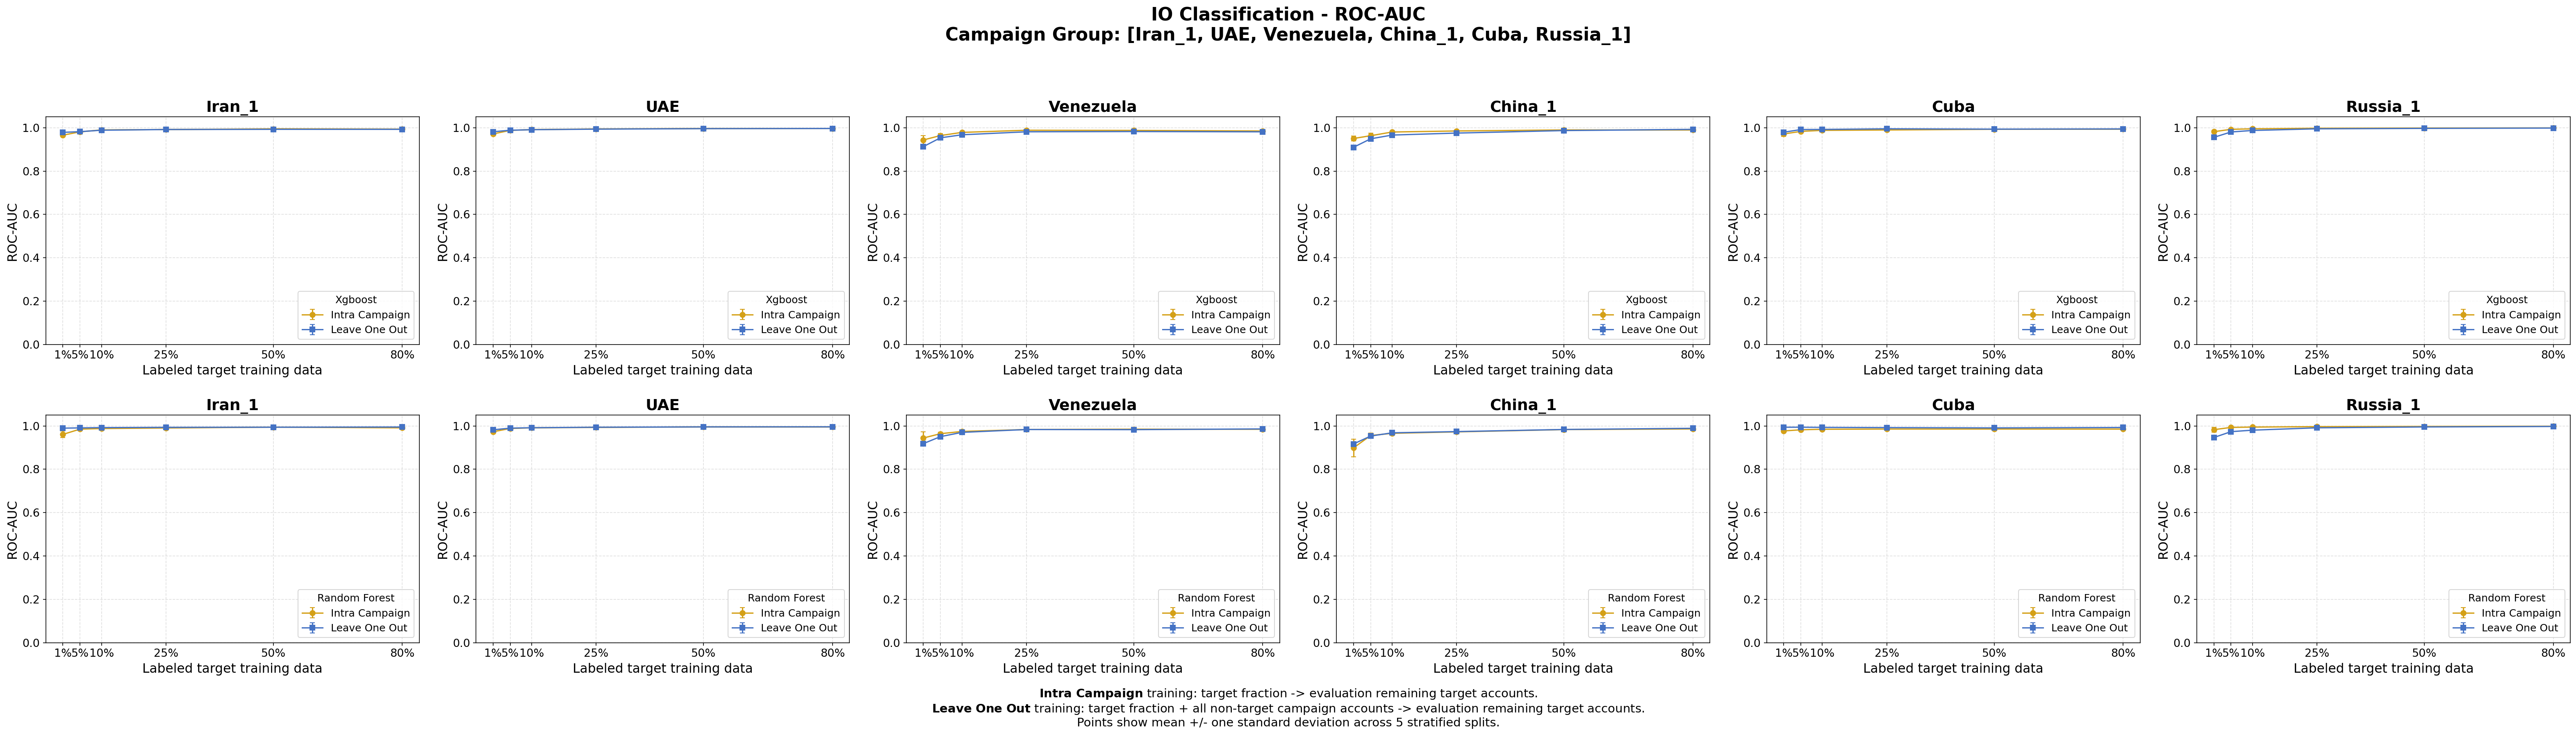

2026-08-18 12:52:08 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_auc_roc_by_campaign.png


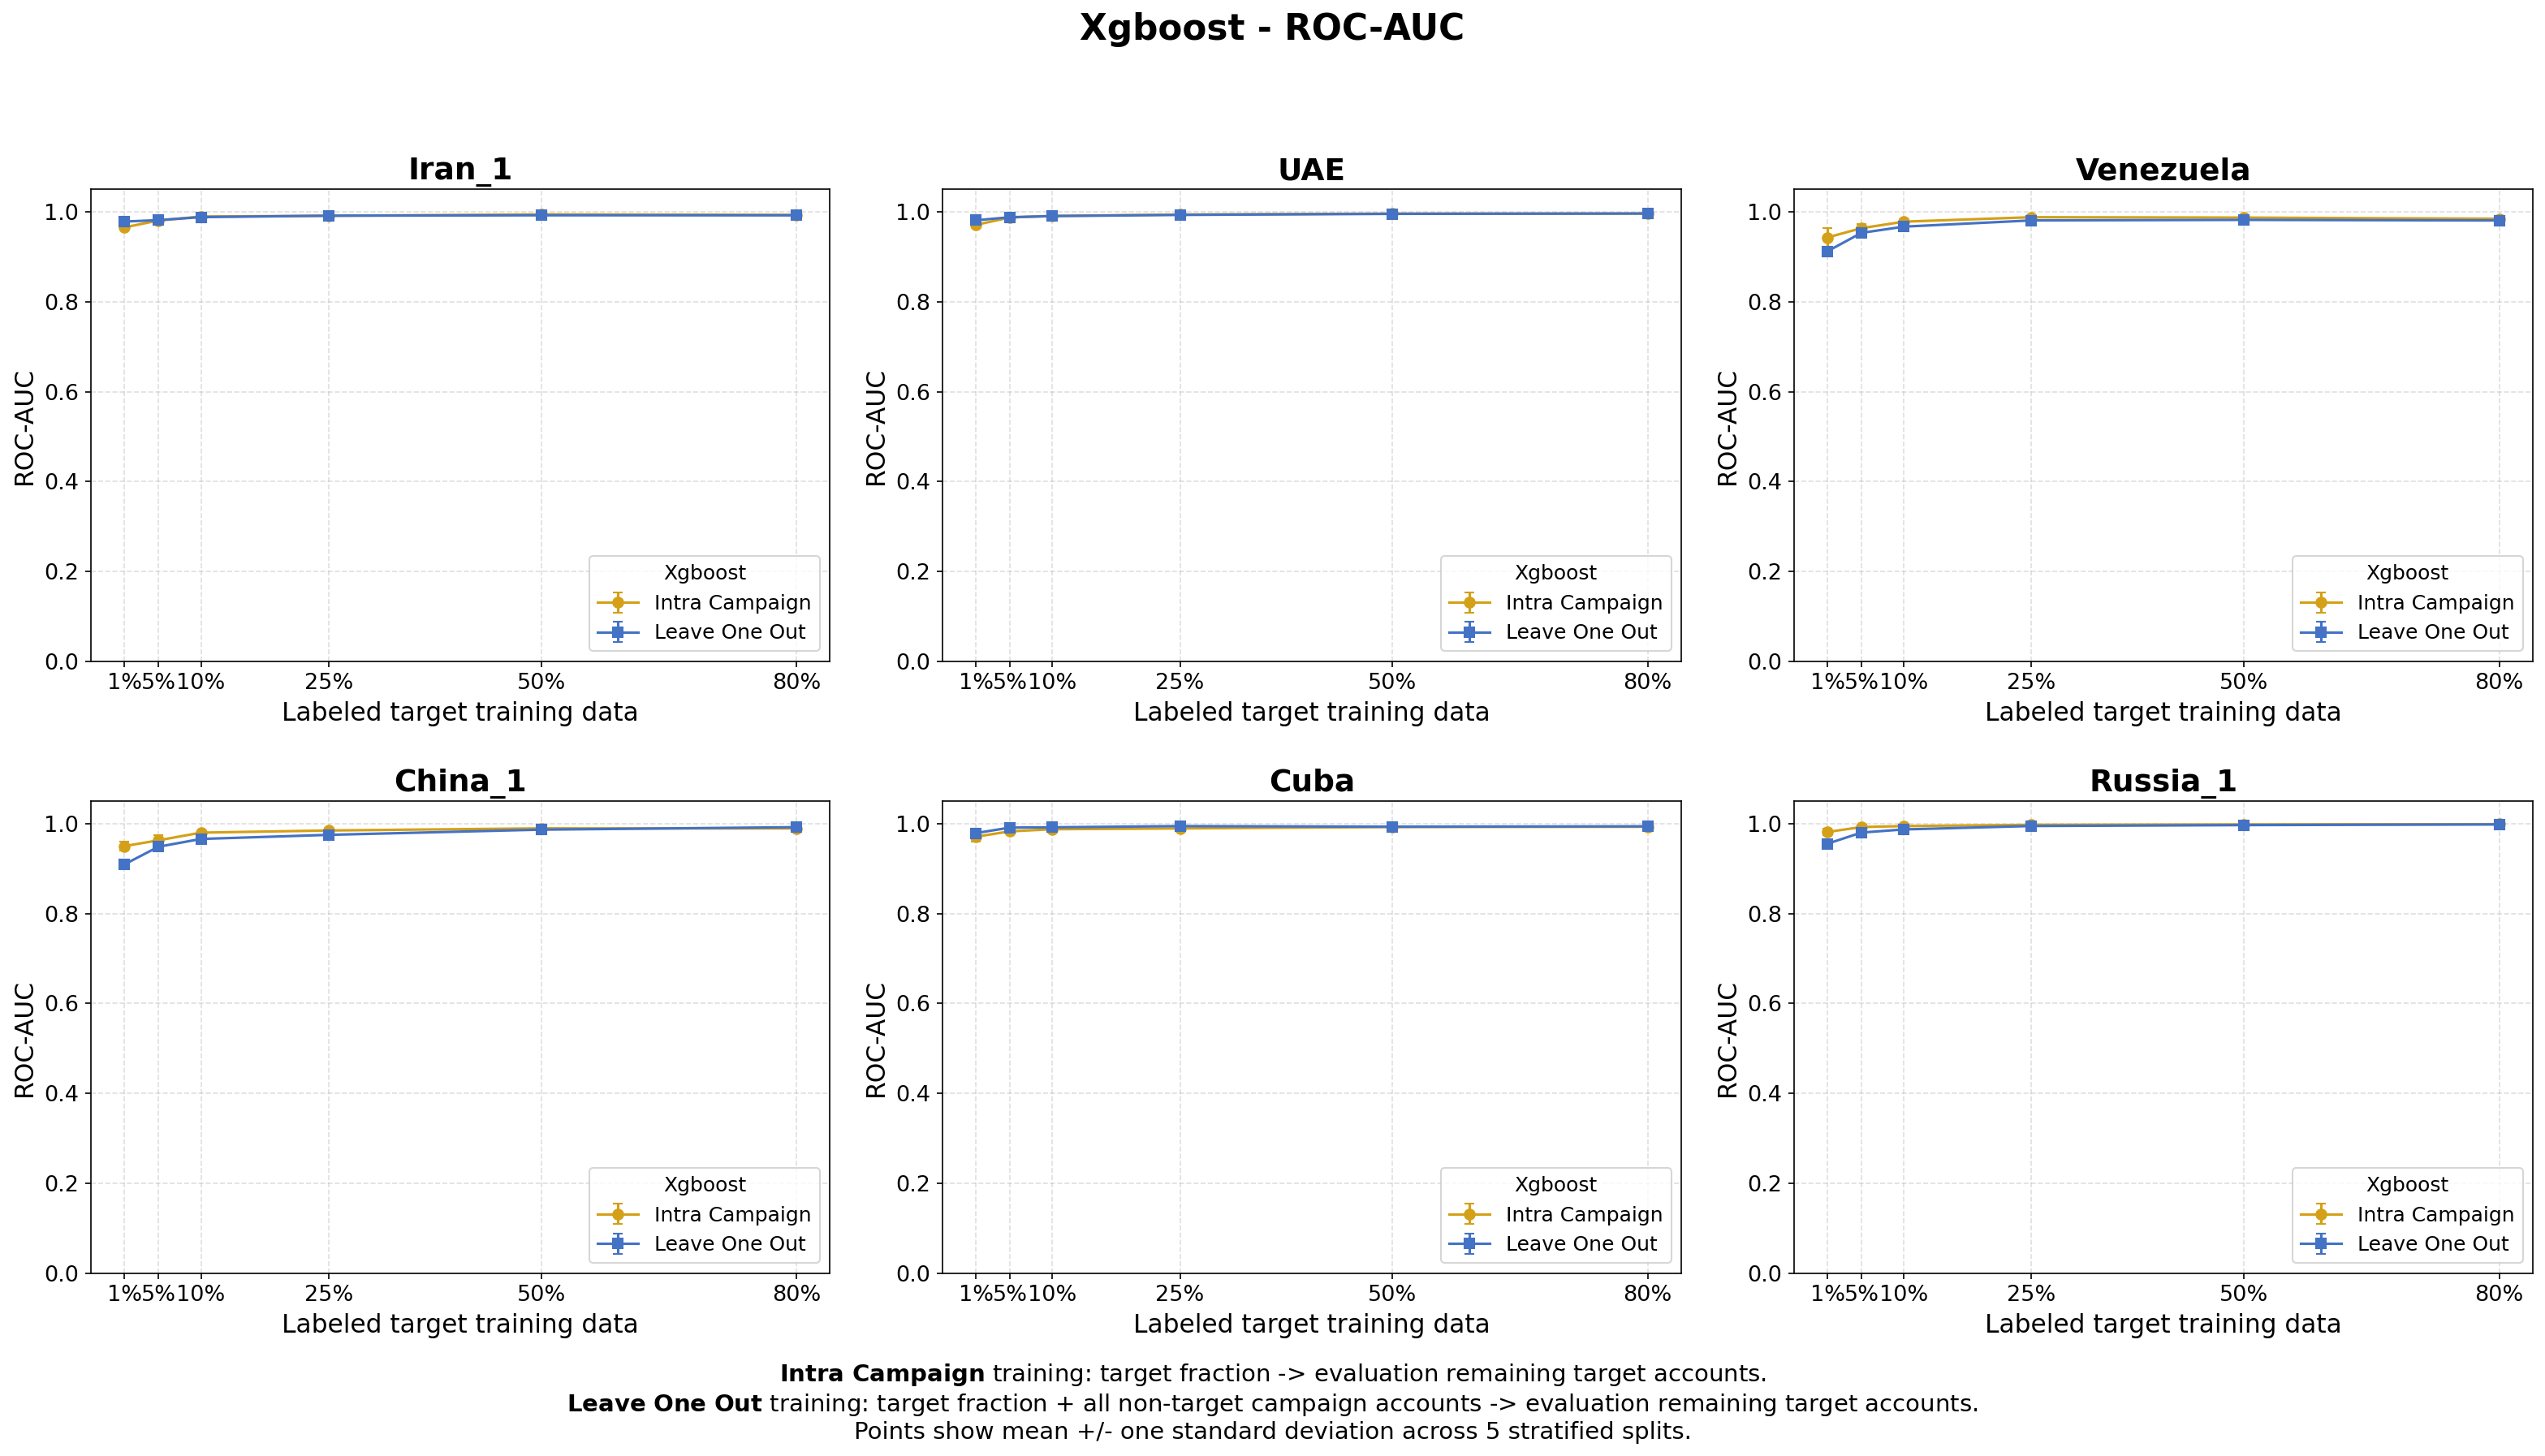

2026-08-18 12:52:12 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_auc_roc_by_campaign.png


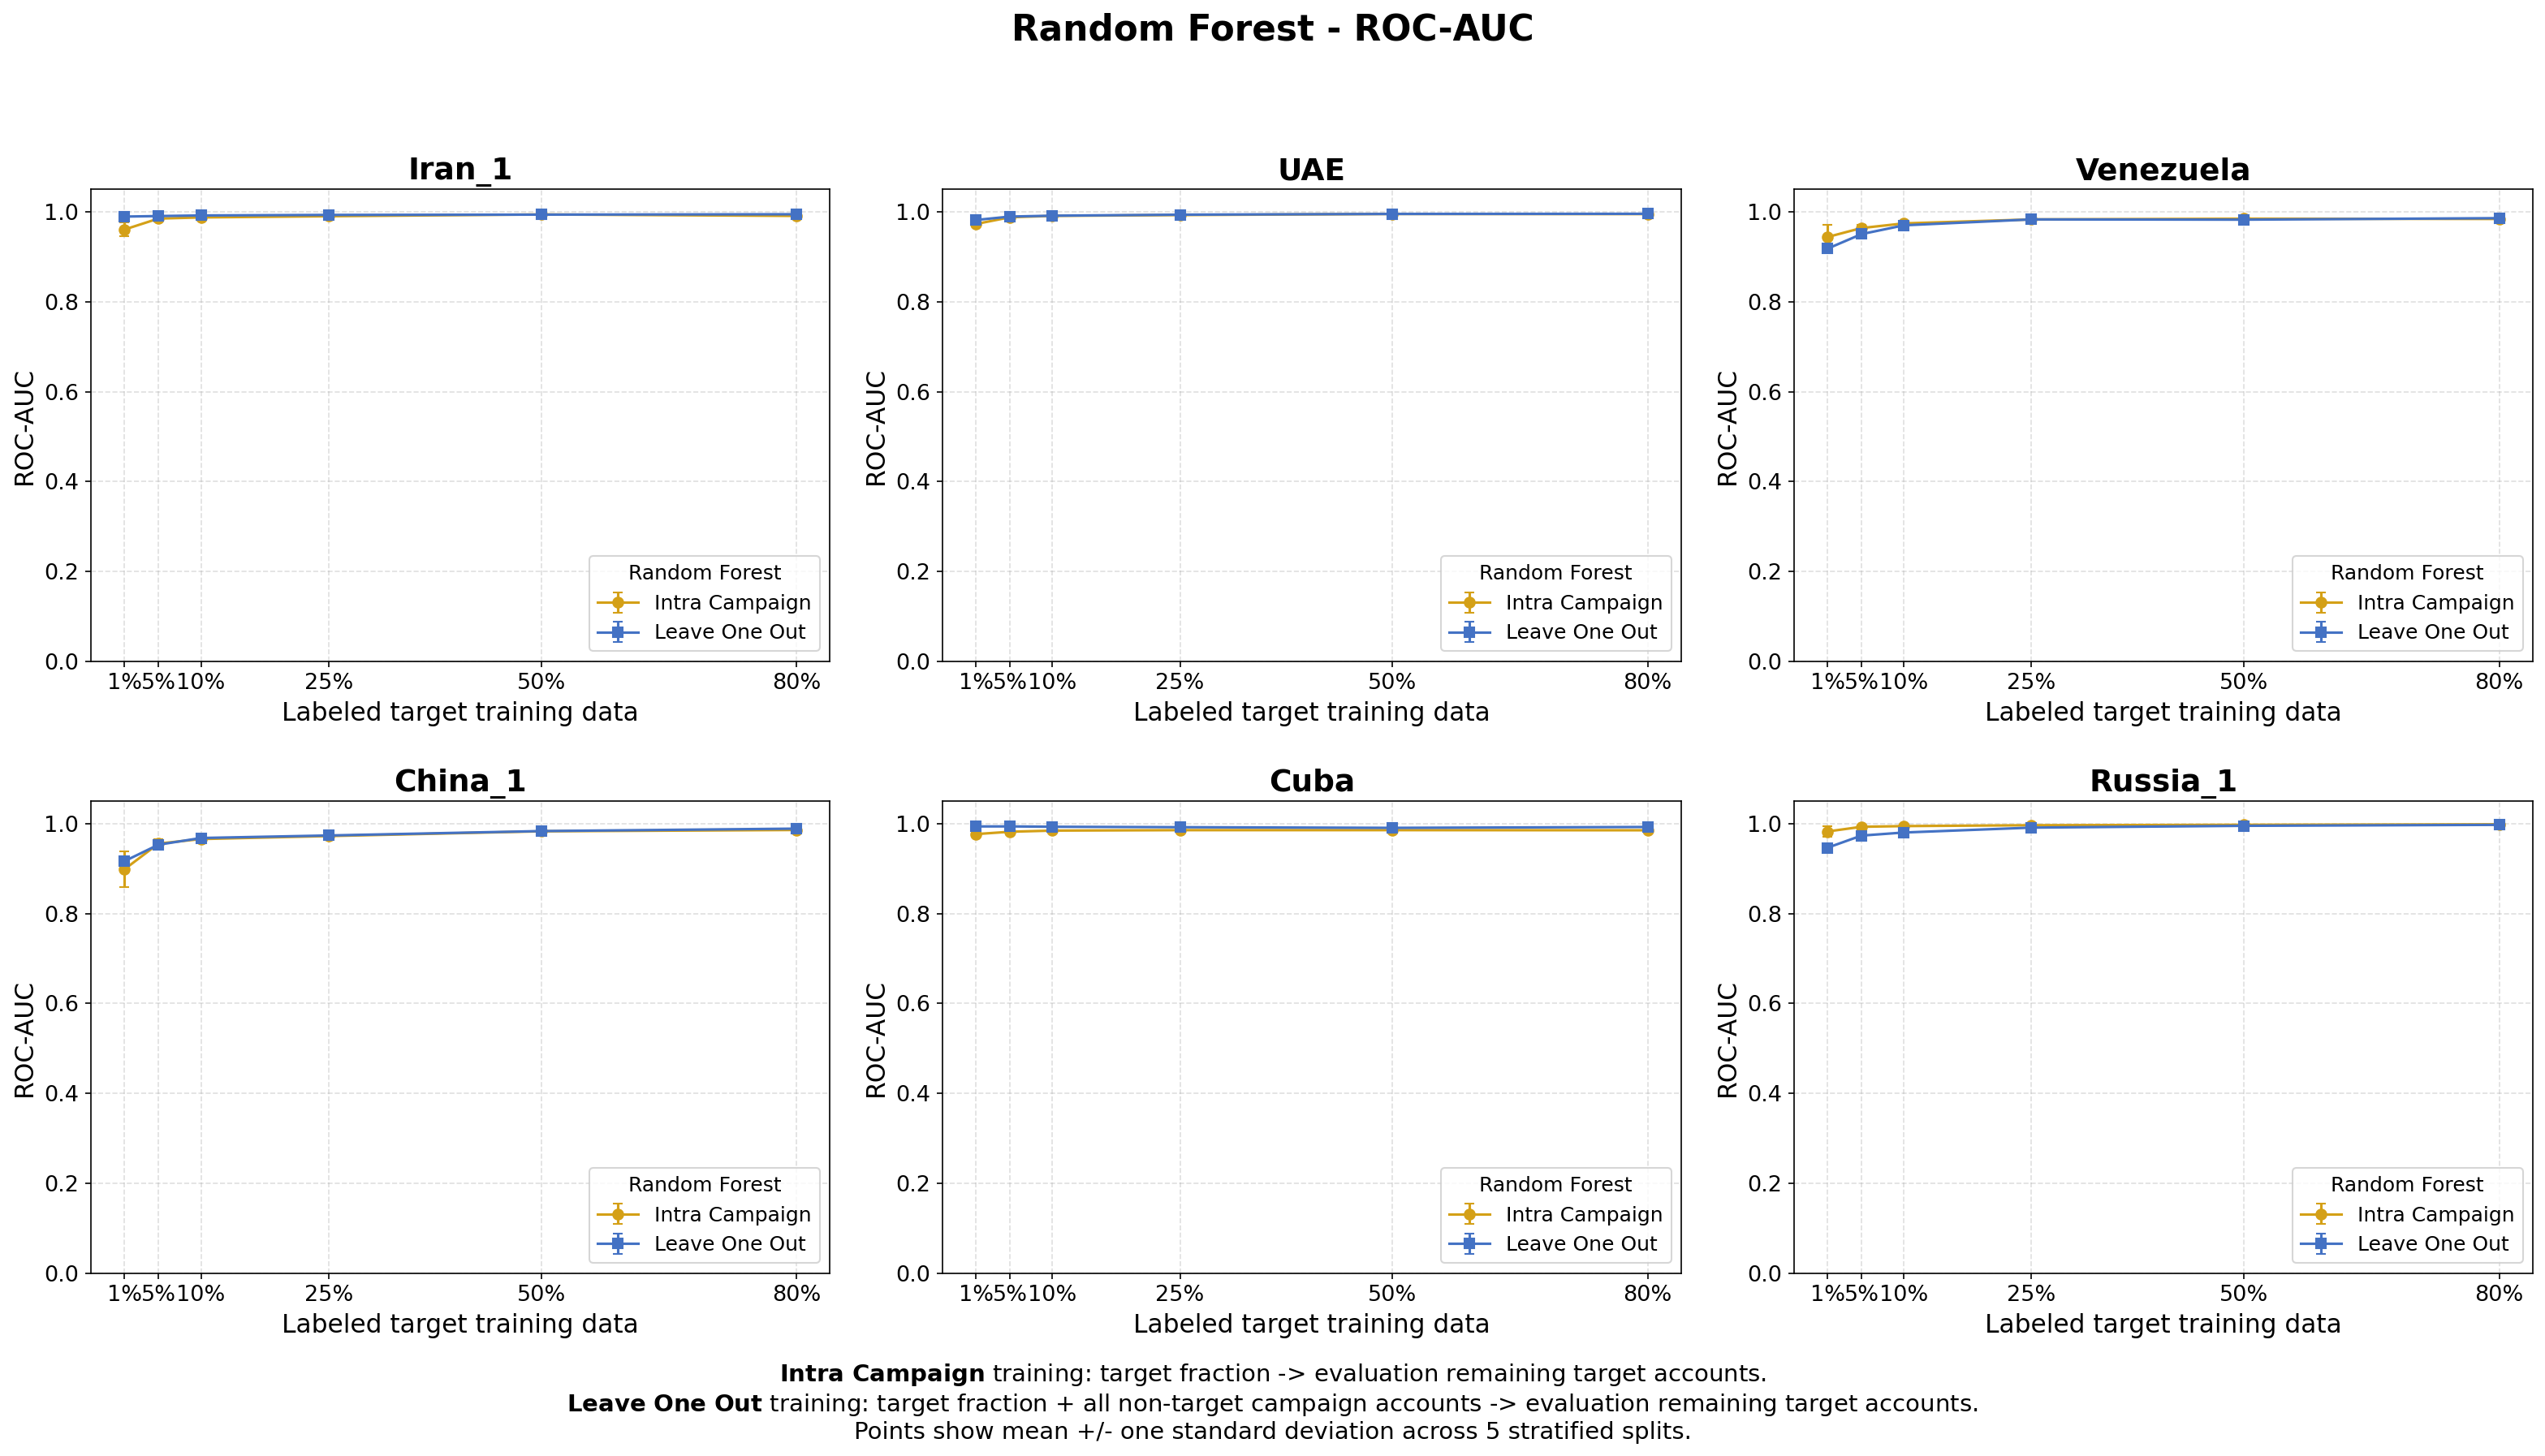

2026-08-18 12:52:19 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_auc_pr.png


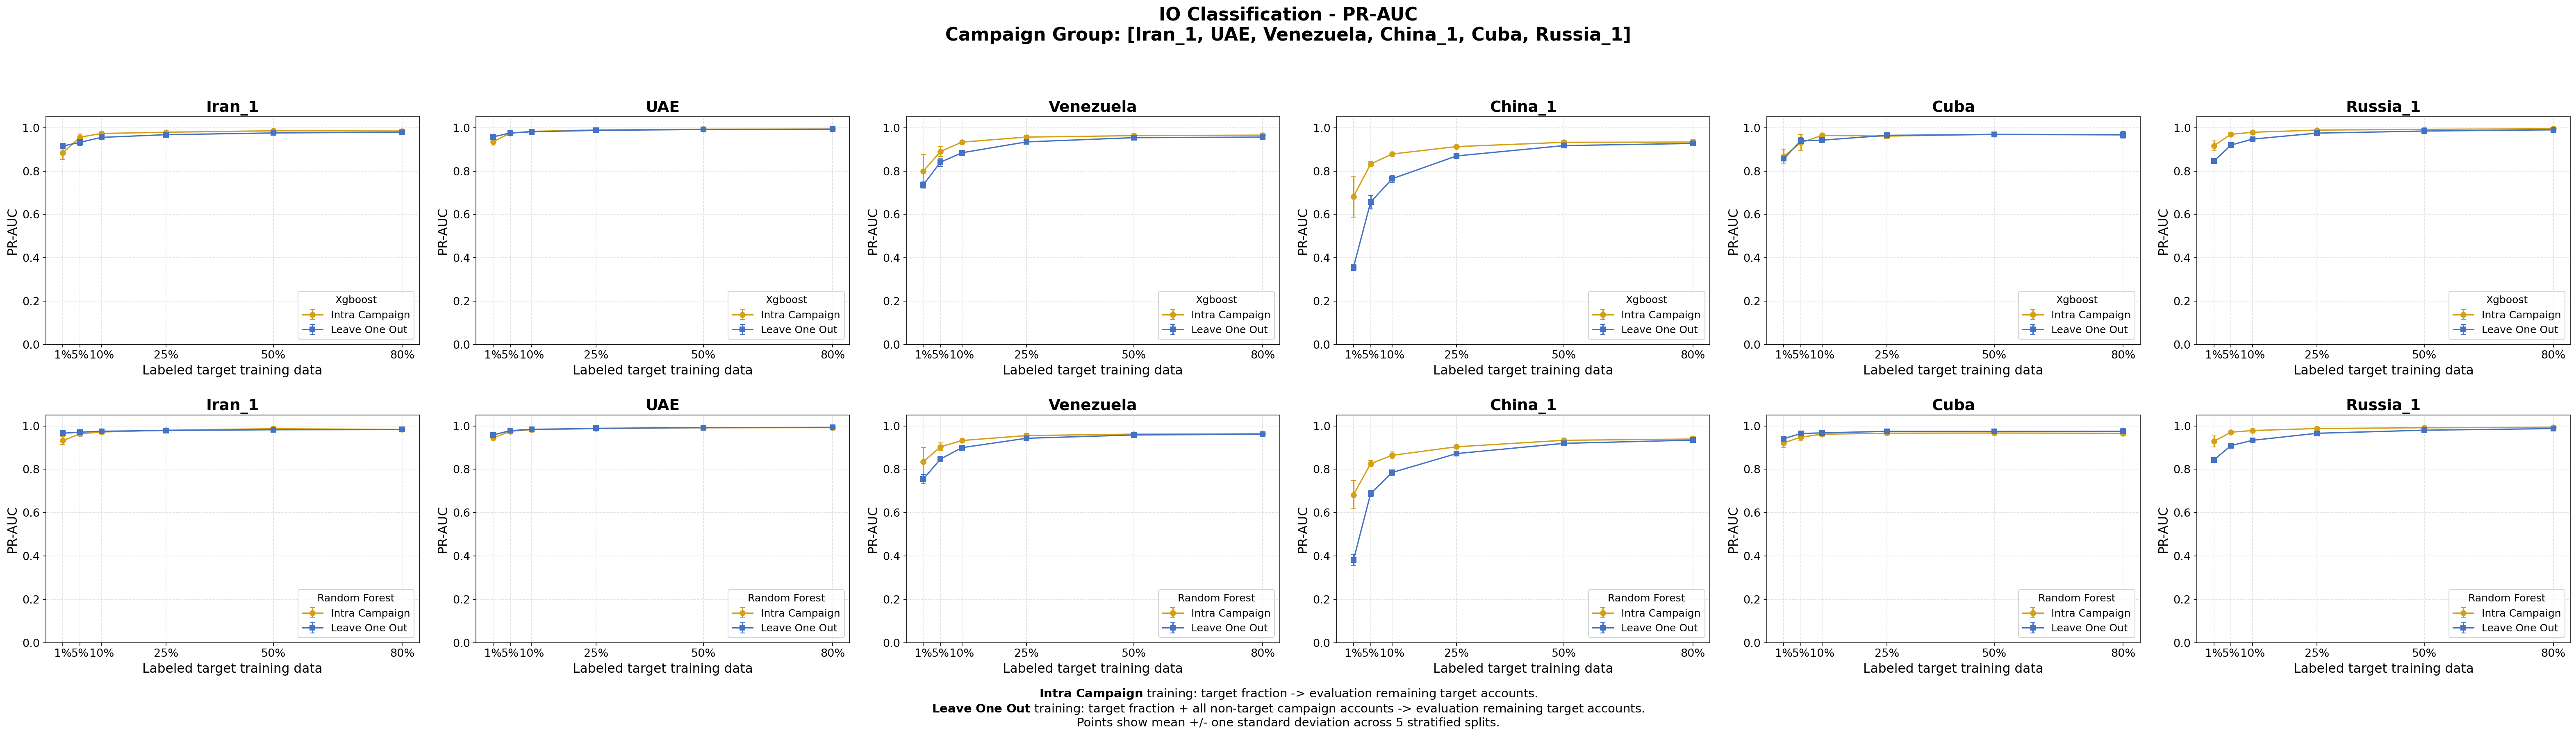

2026-08-18 12:52:23 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_auc_pr_by_campaign.png


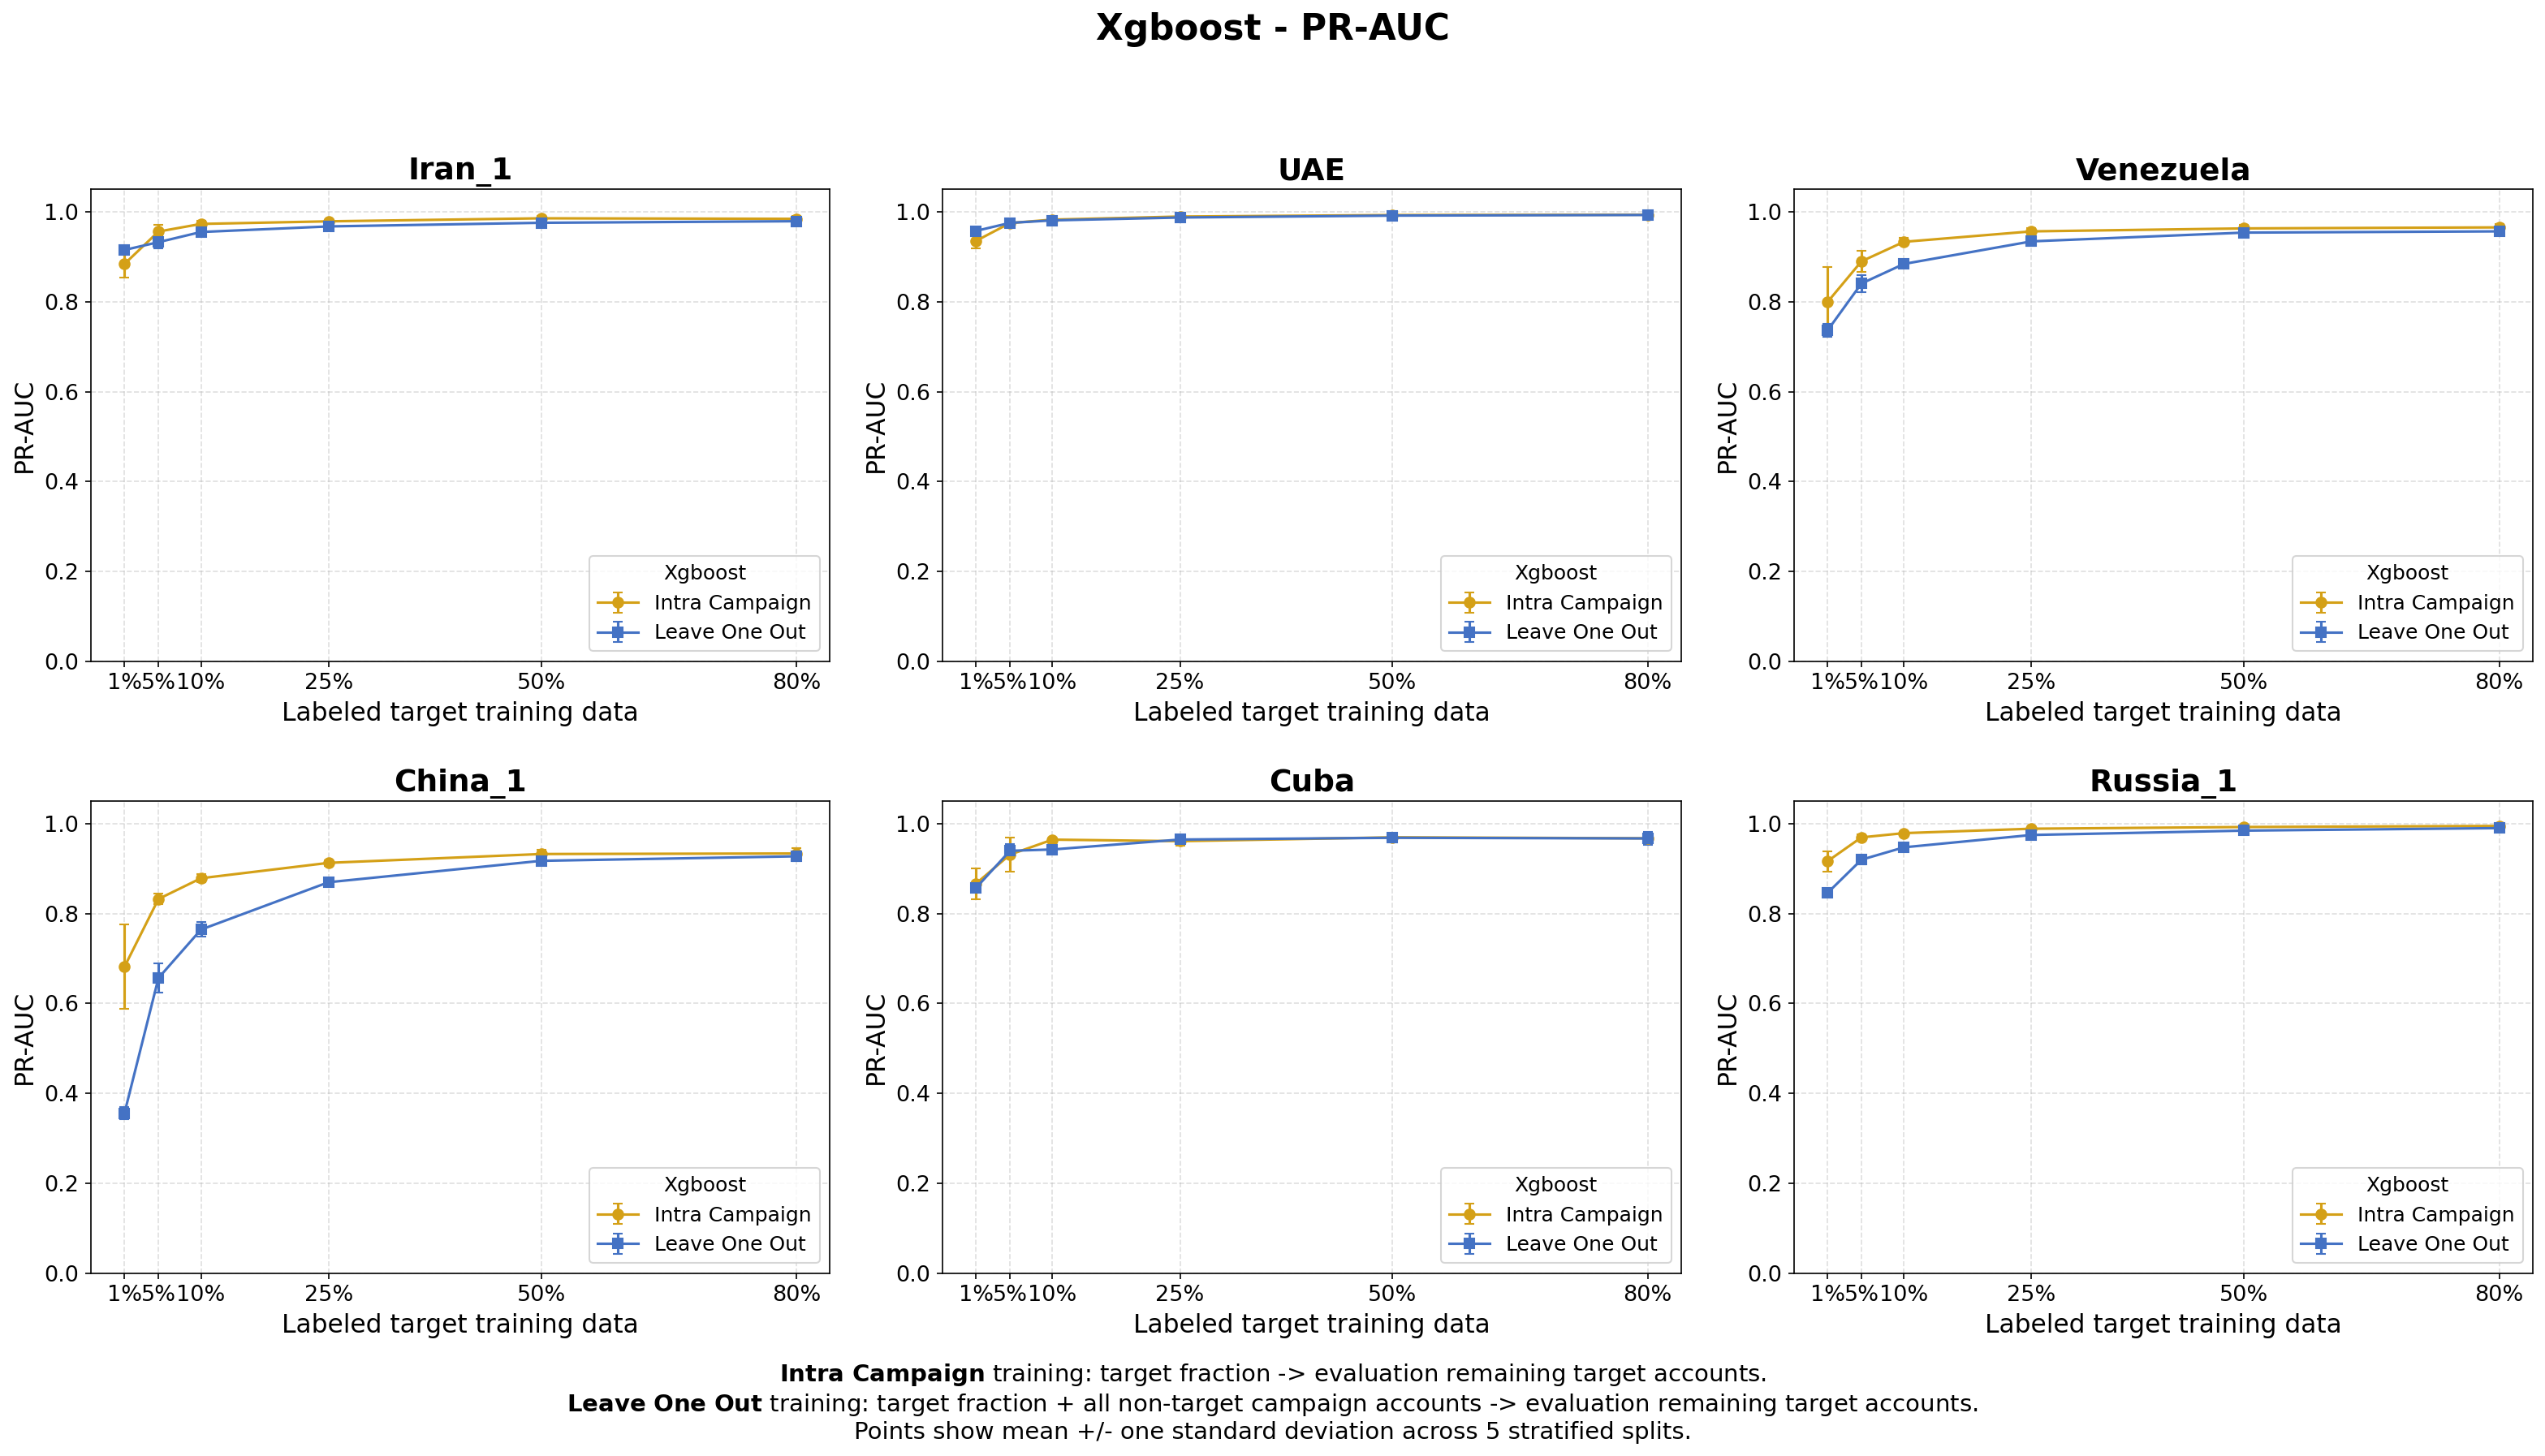

2026-08-18 12:52:26 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_auc_pr_by_campaign.png


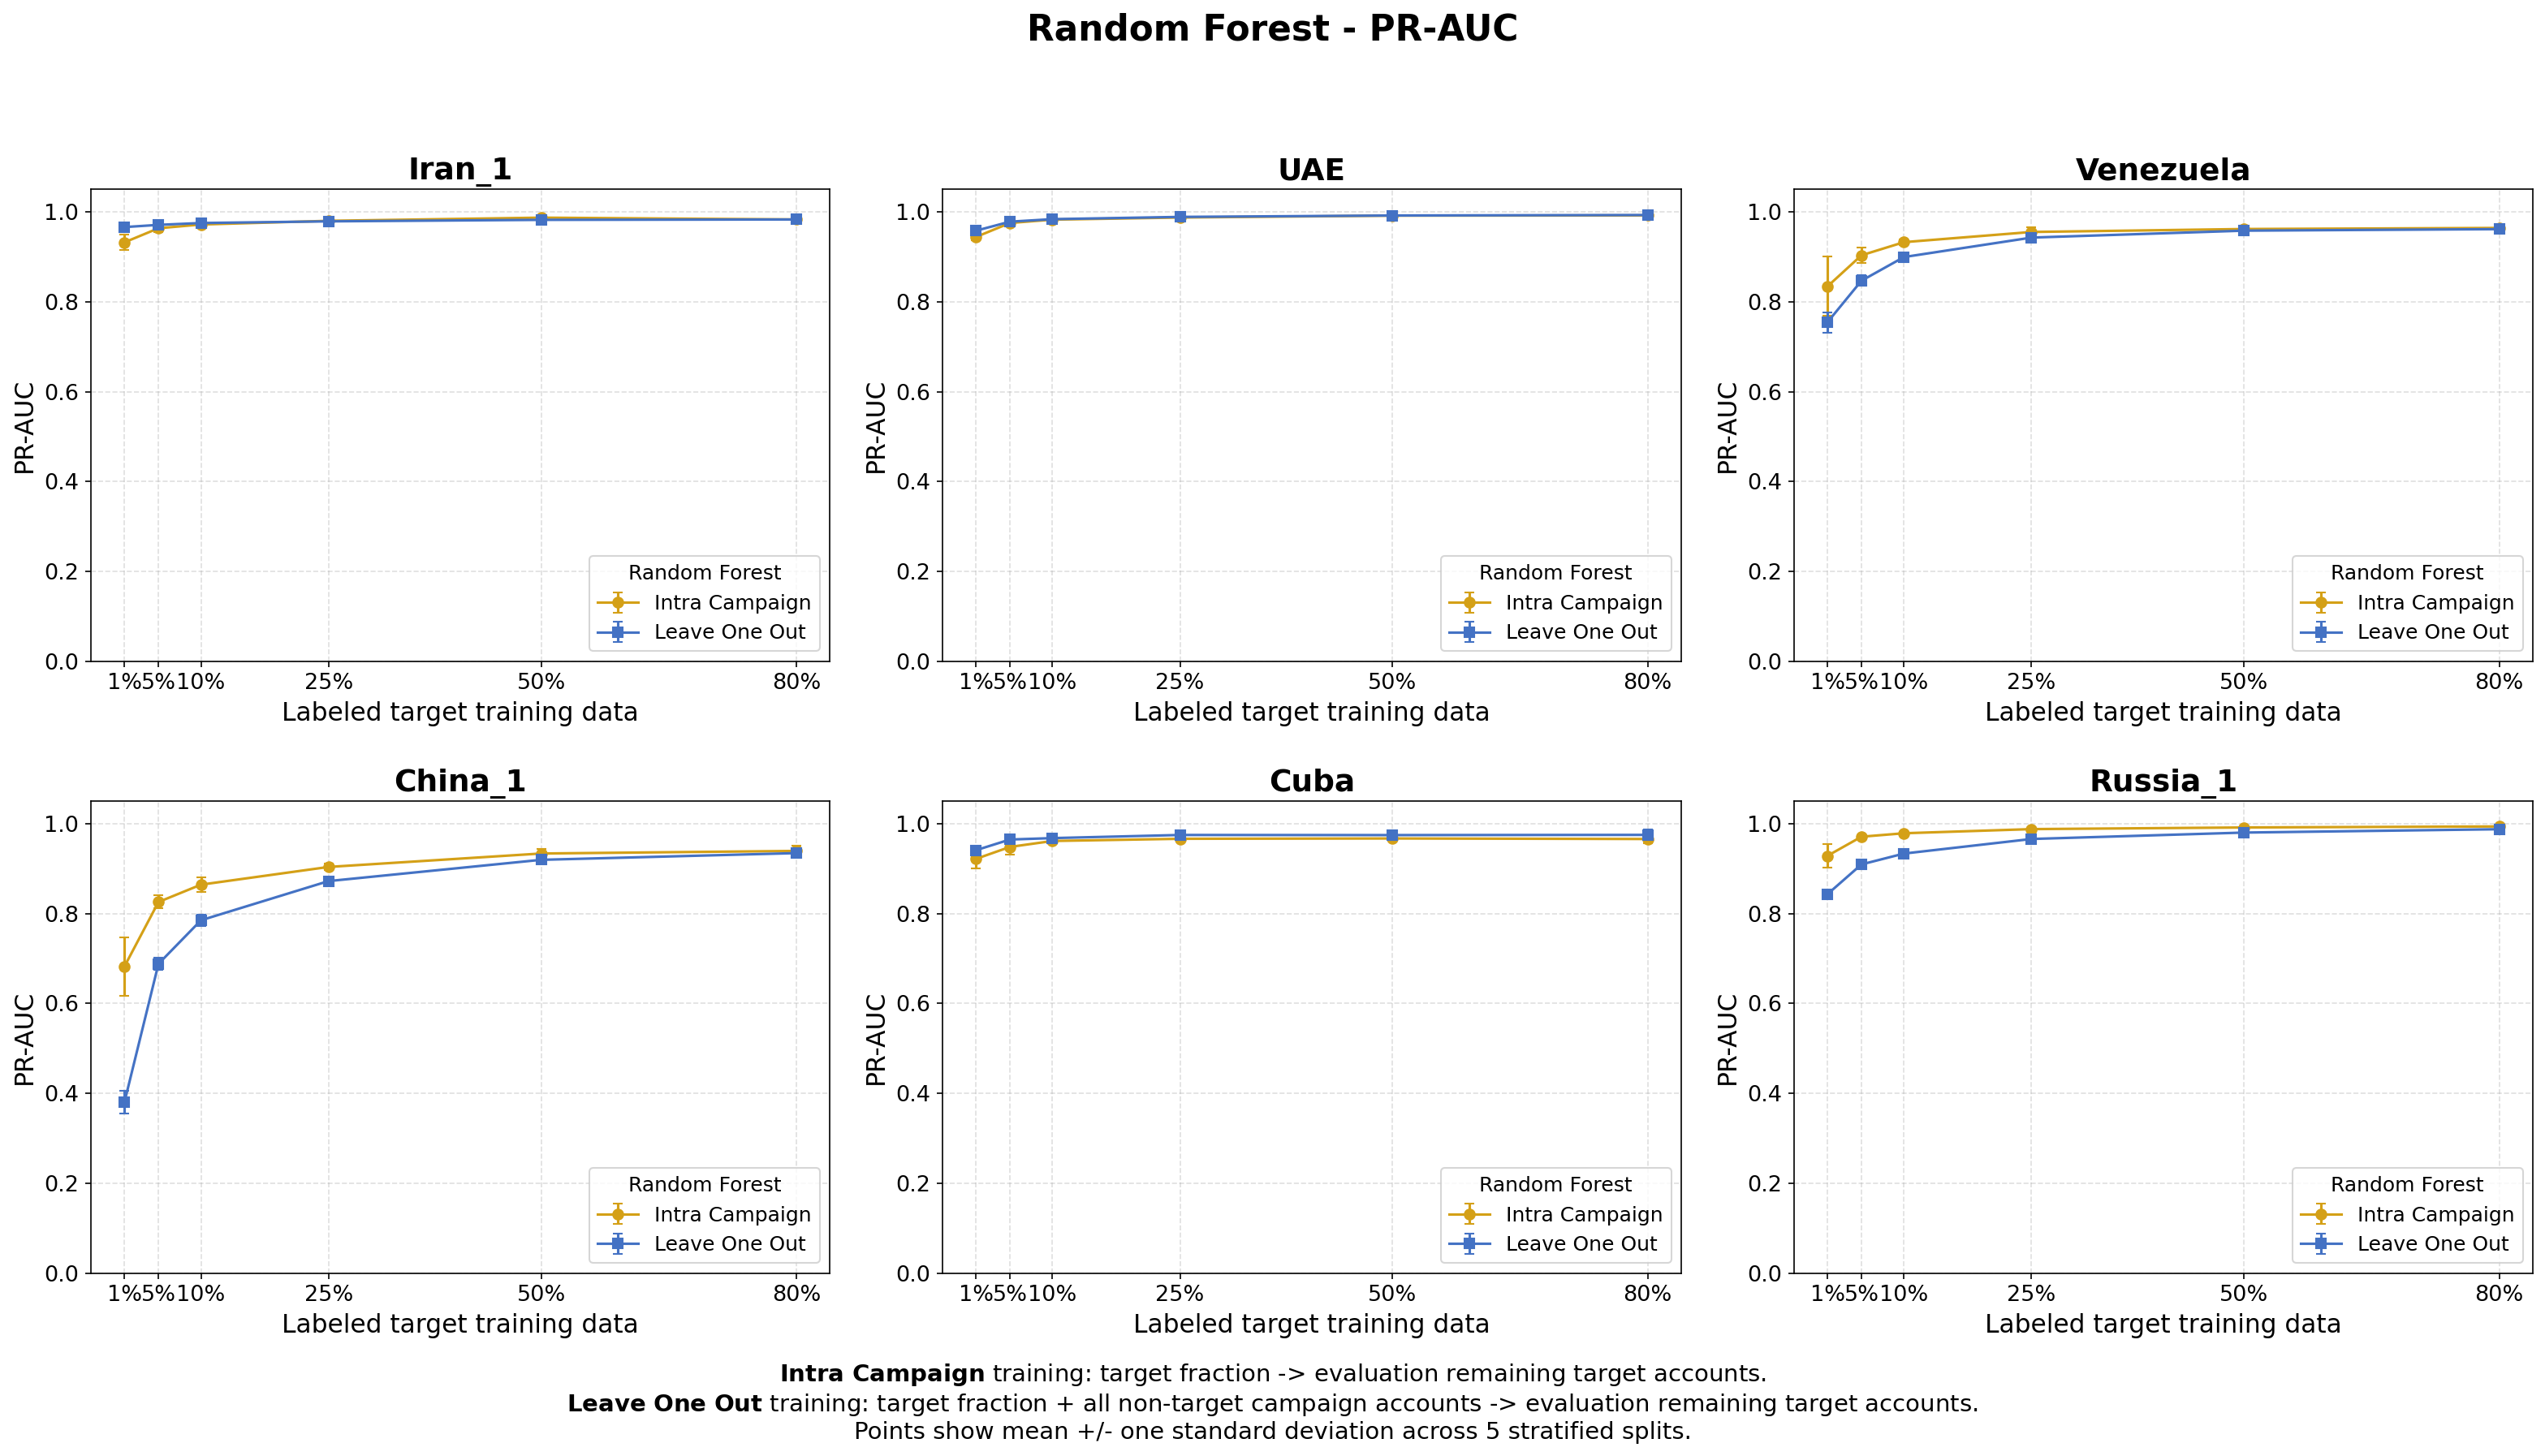

2026-08-18 12:52:33 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_f1.png


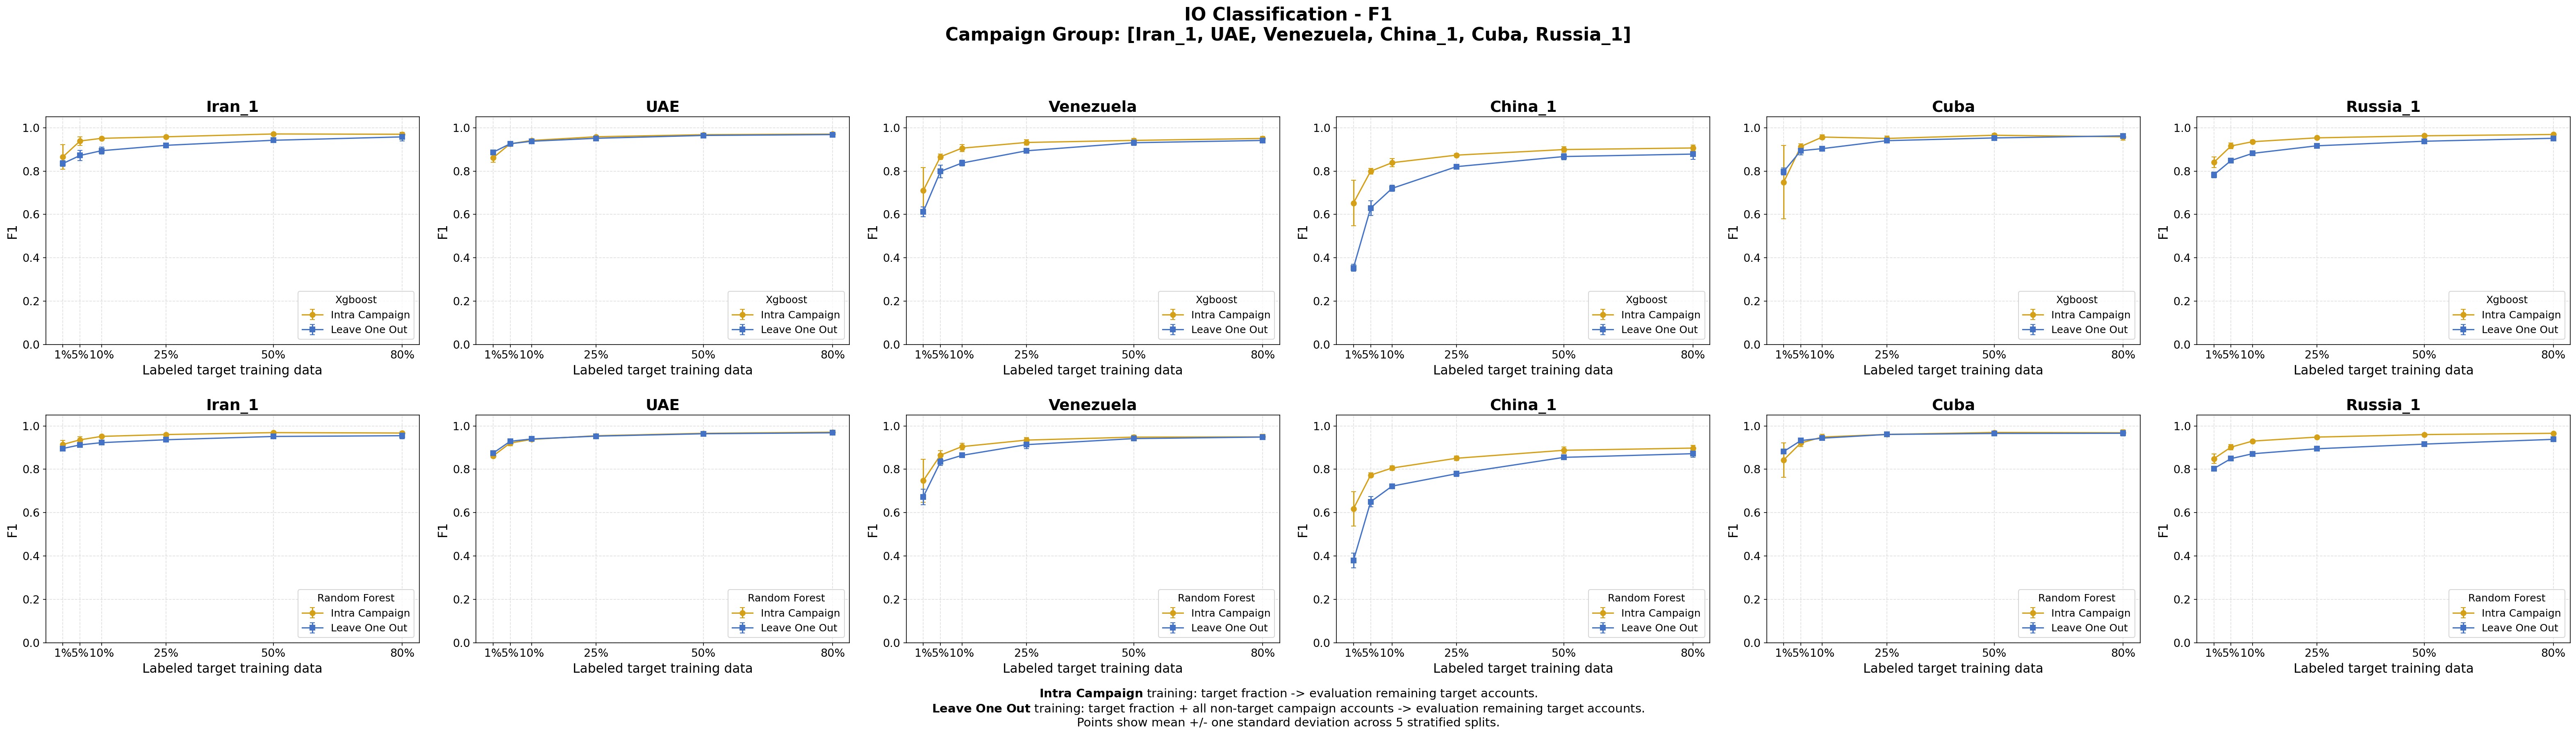

2026-08-18 12:52:37 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_f1_by_campaign.png


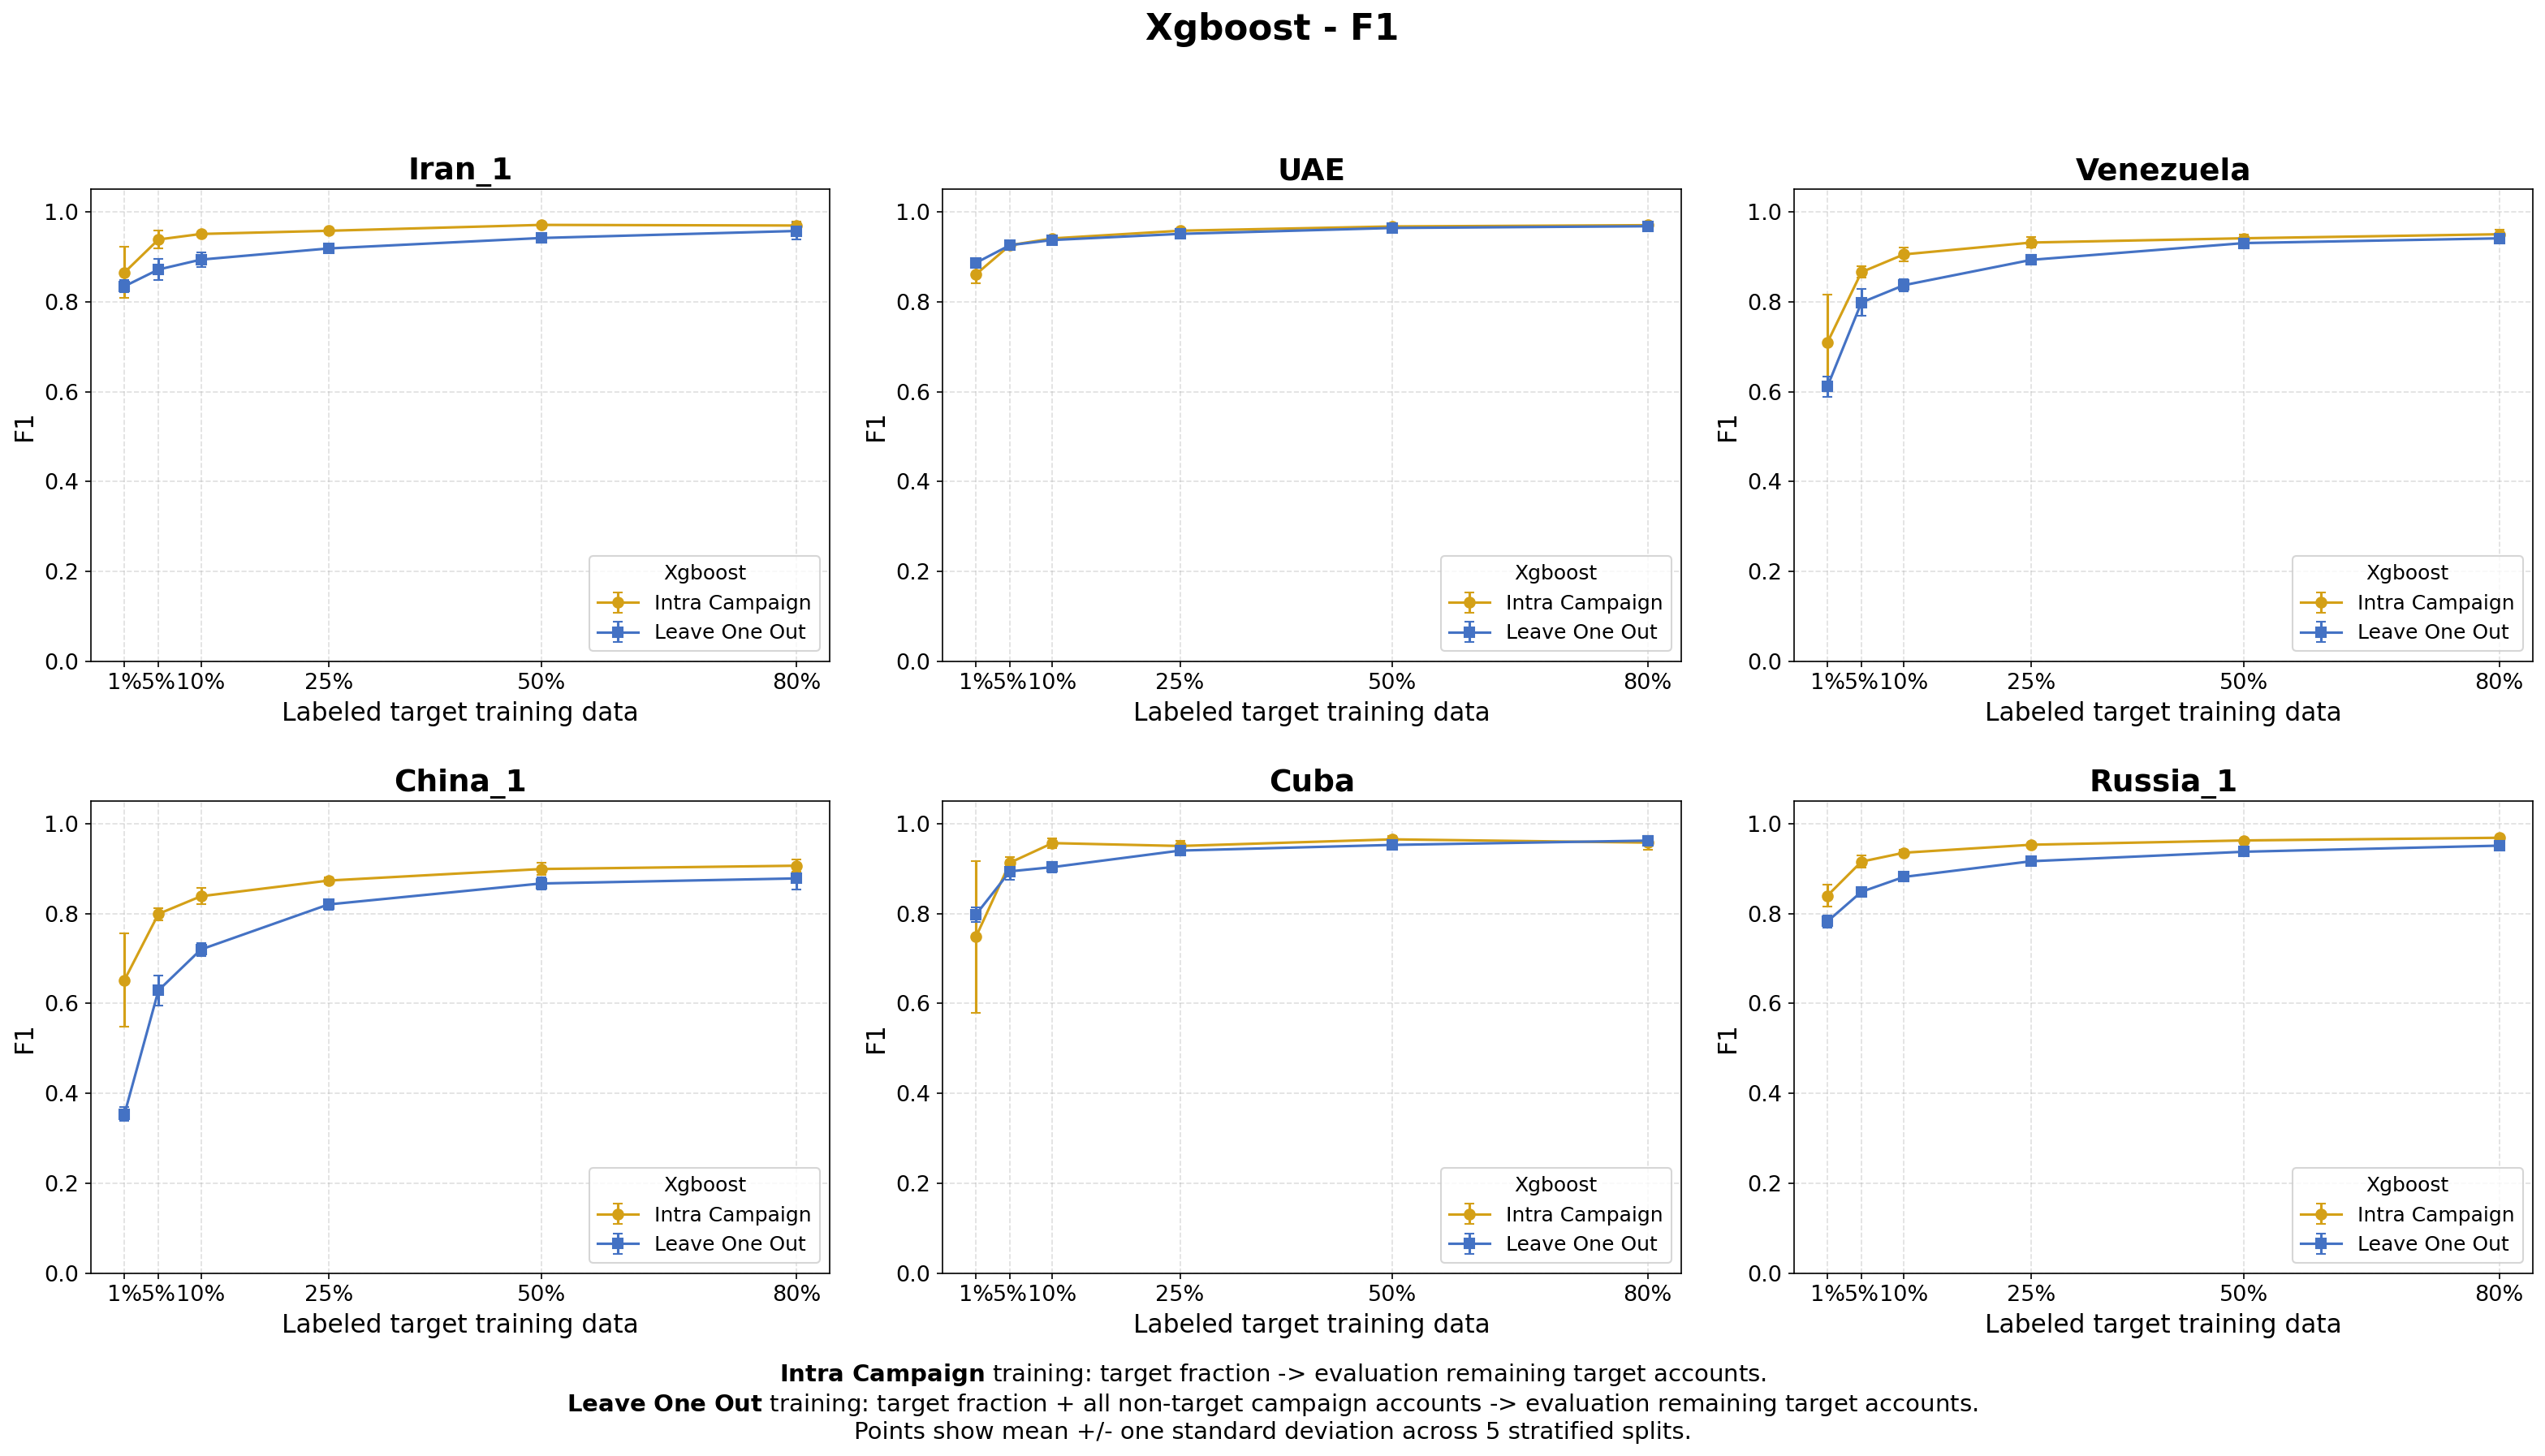

2026-08-18 12:52:40 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_f1_by_campaign.png


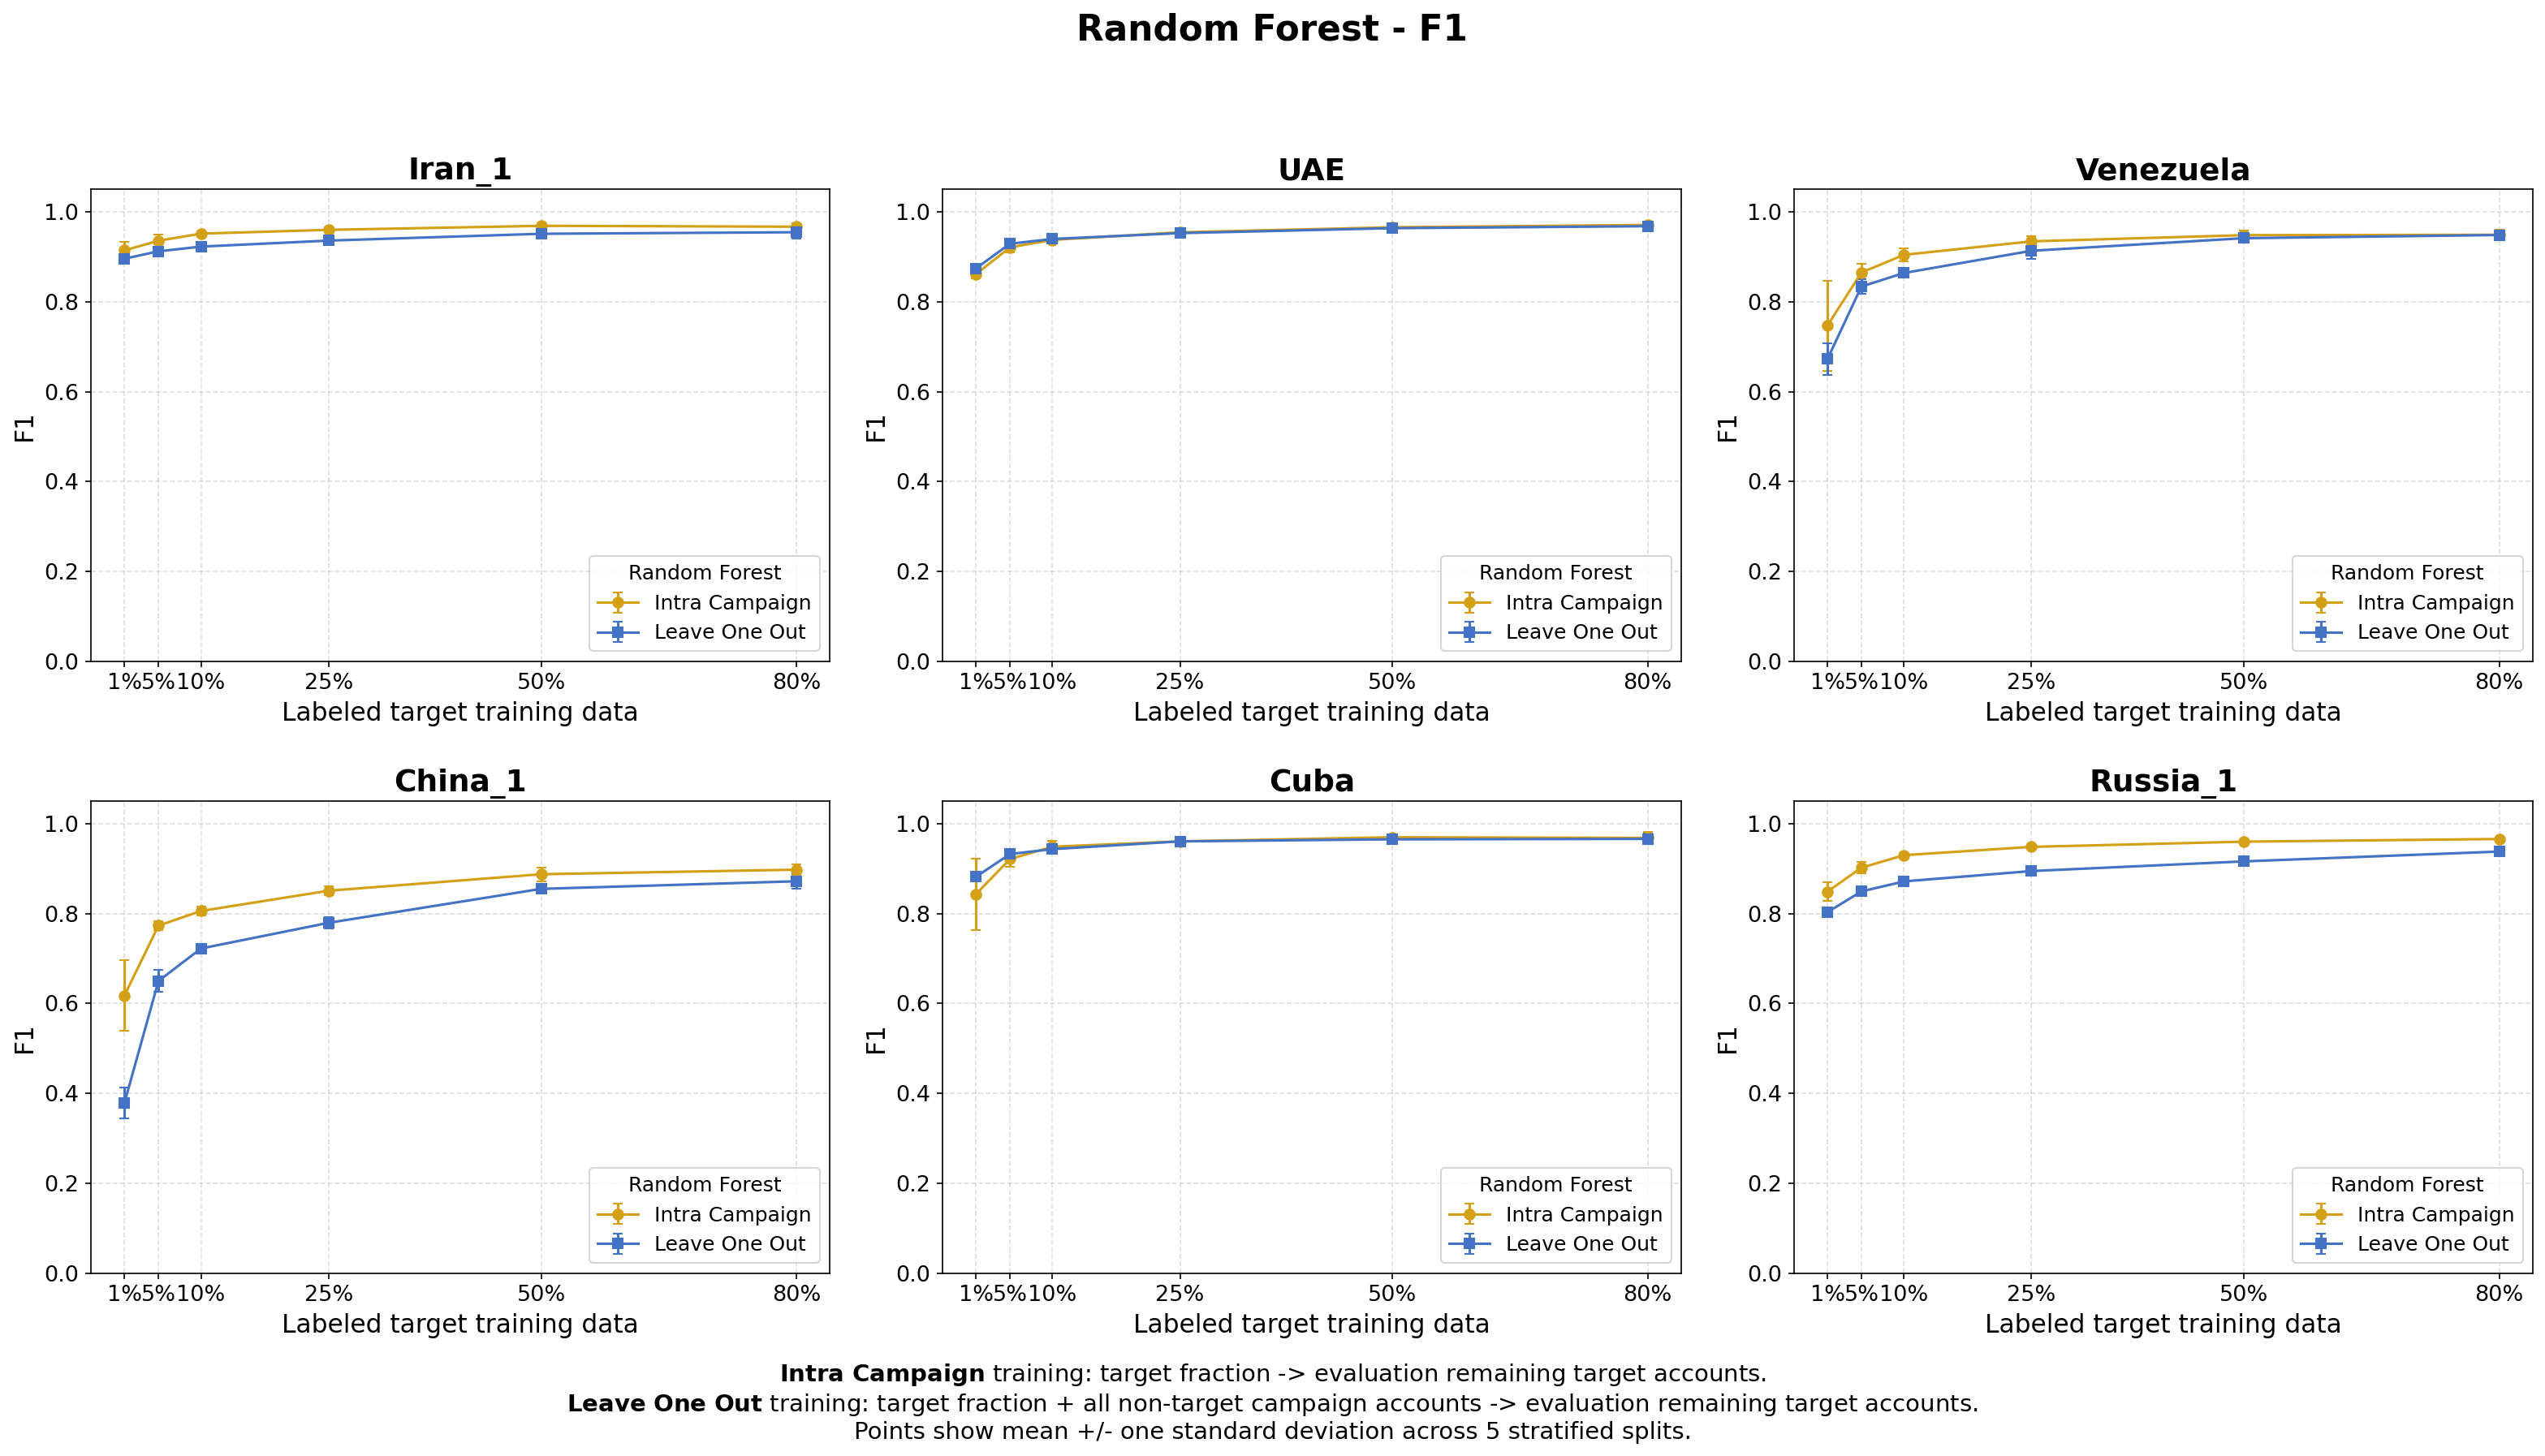

2026-08-18 12:52:47 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_recall.png


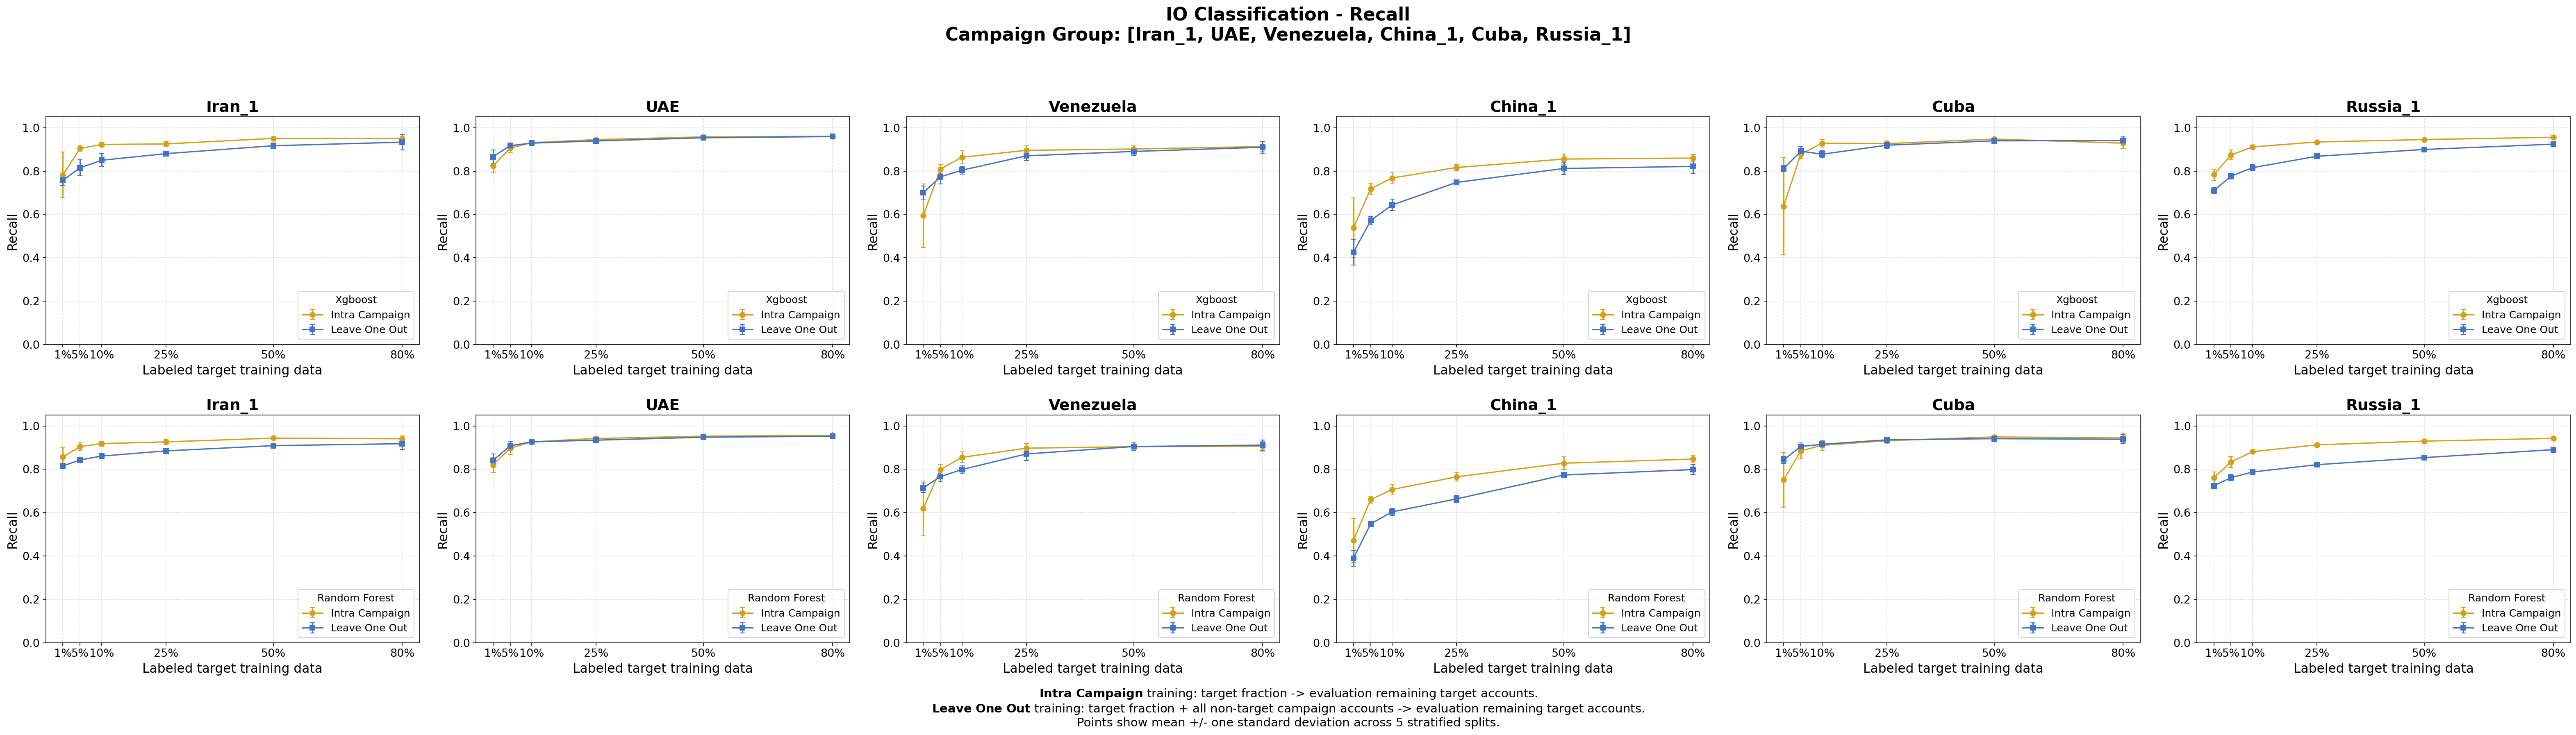

2026-08-18 12:52:51 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_recall_by_campaign.png


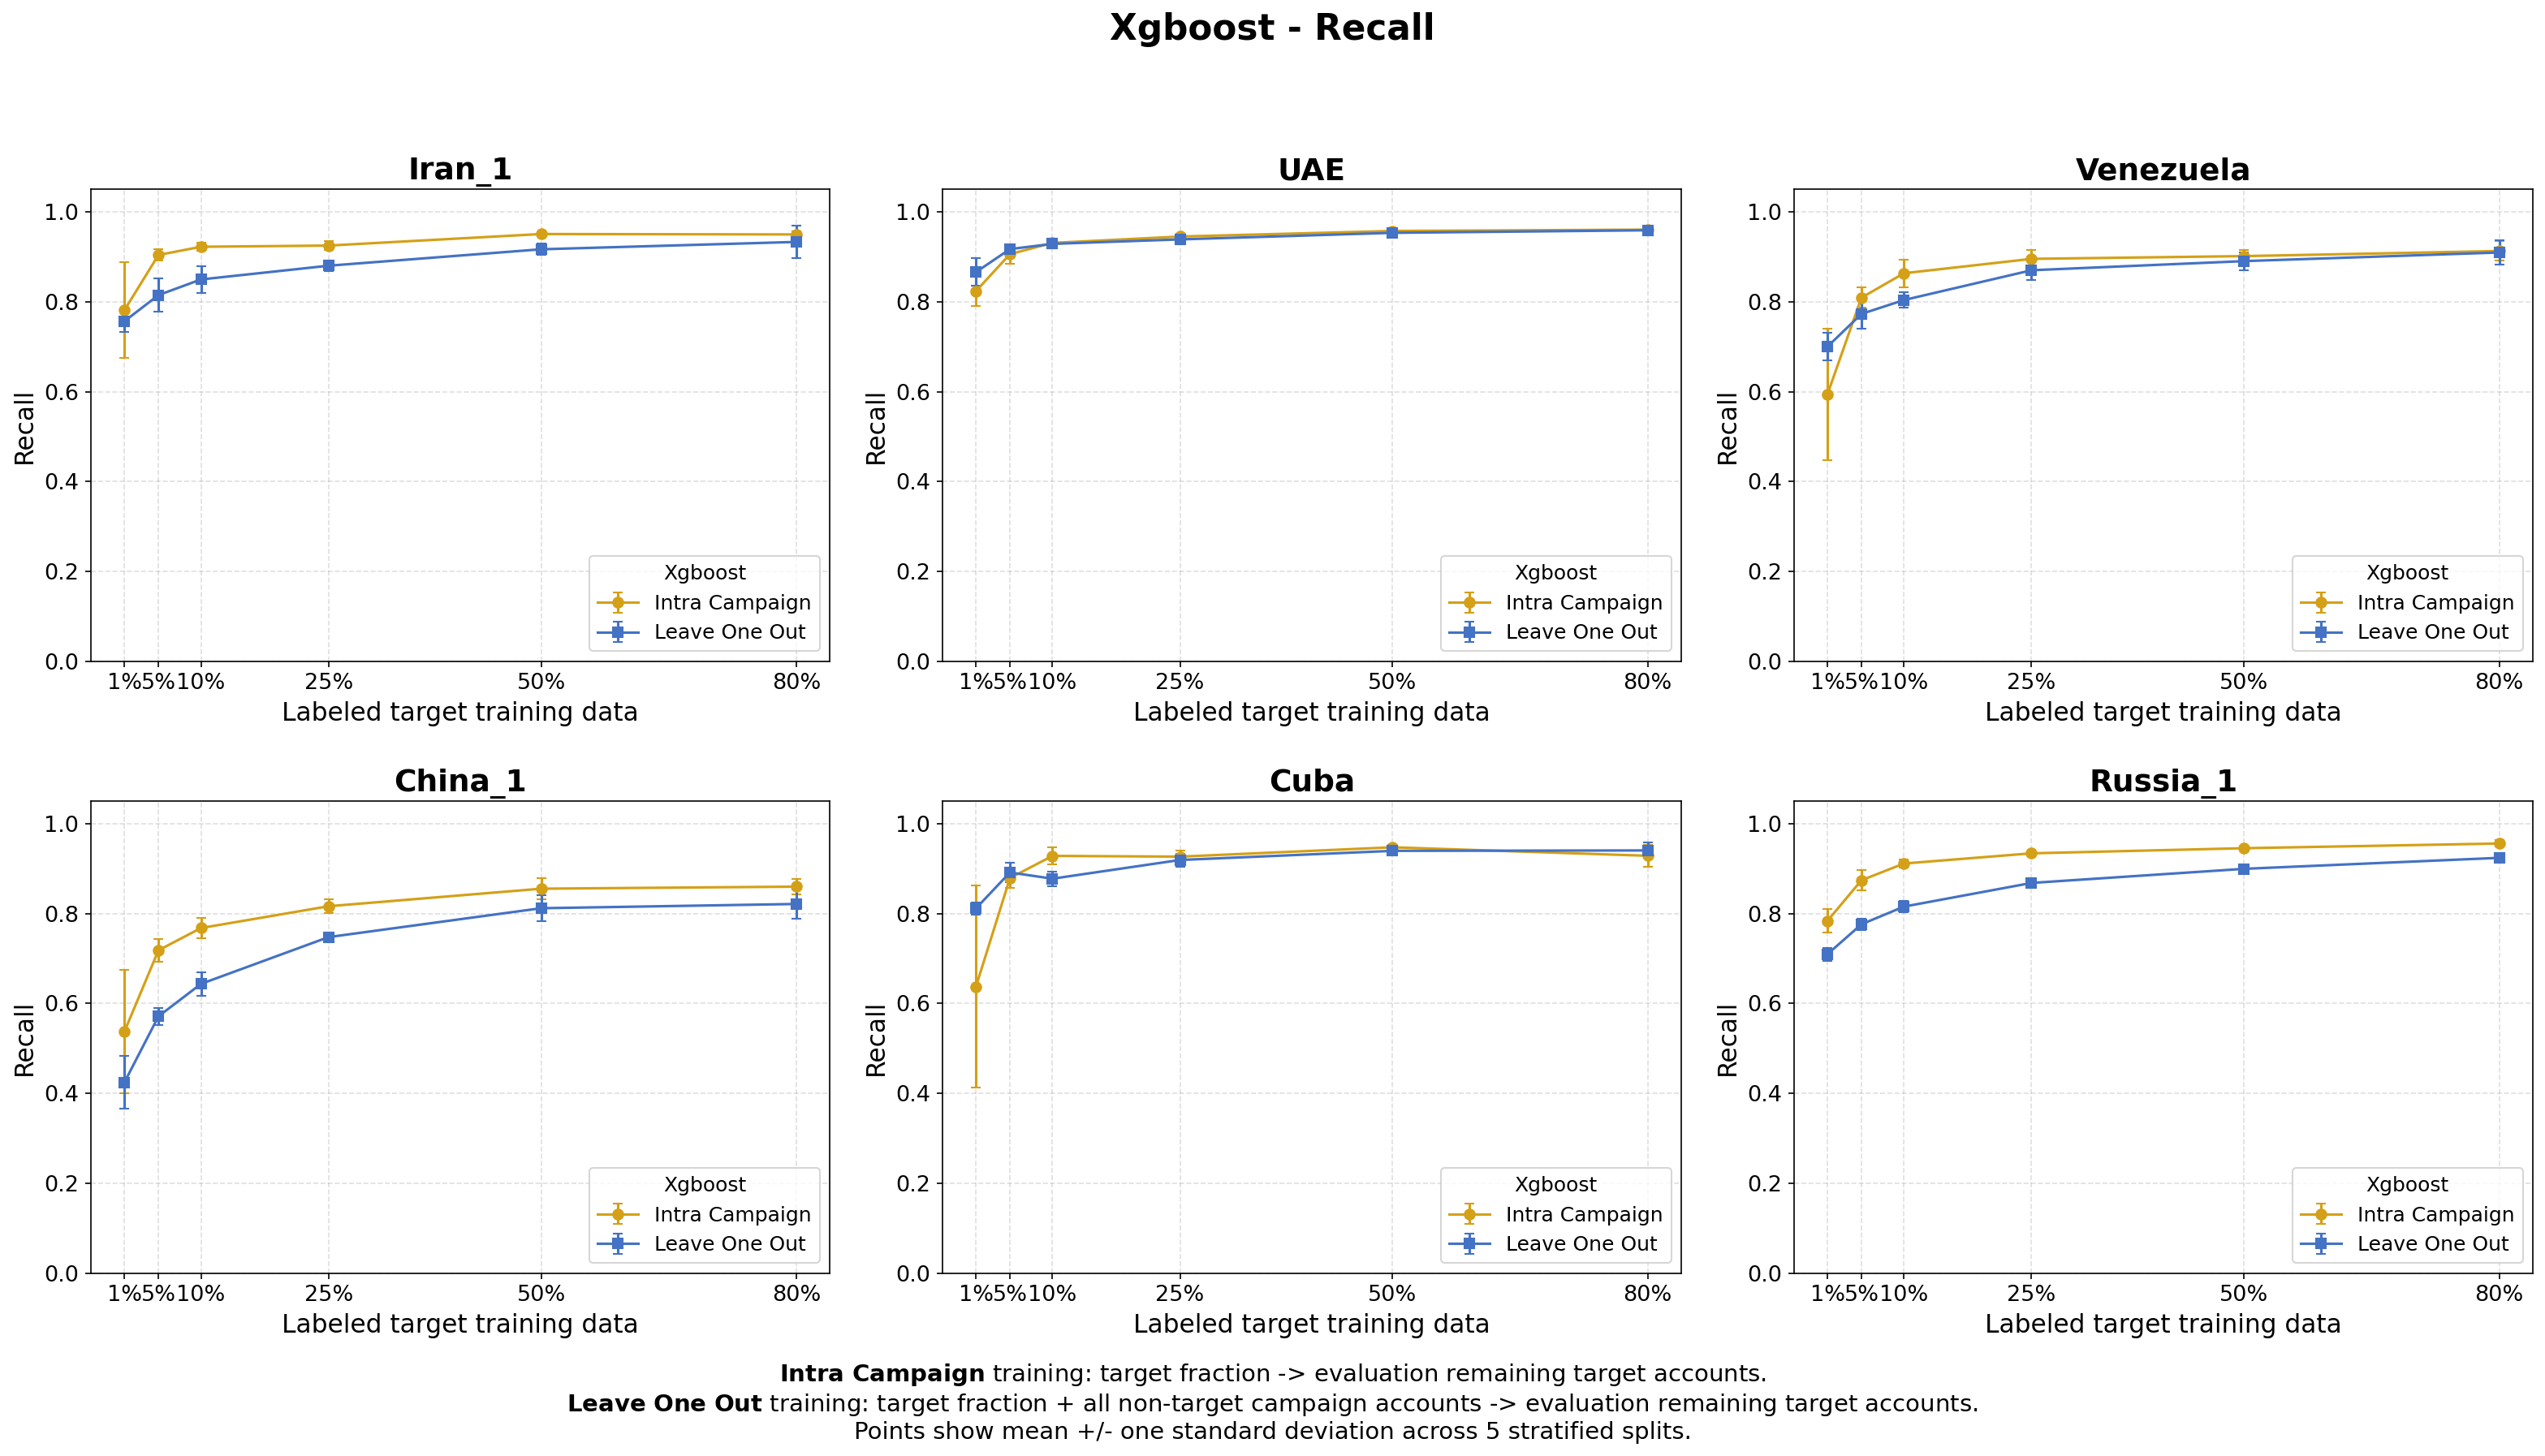

2026-08-18 12:52:54 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_recall_by_campaign.png


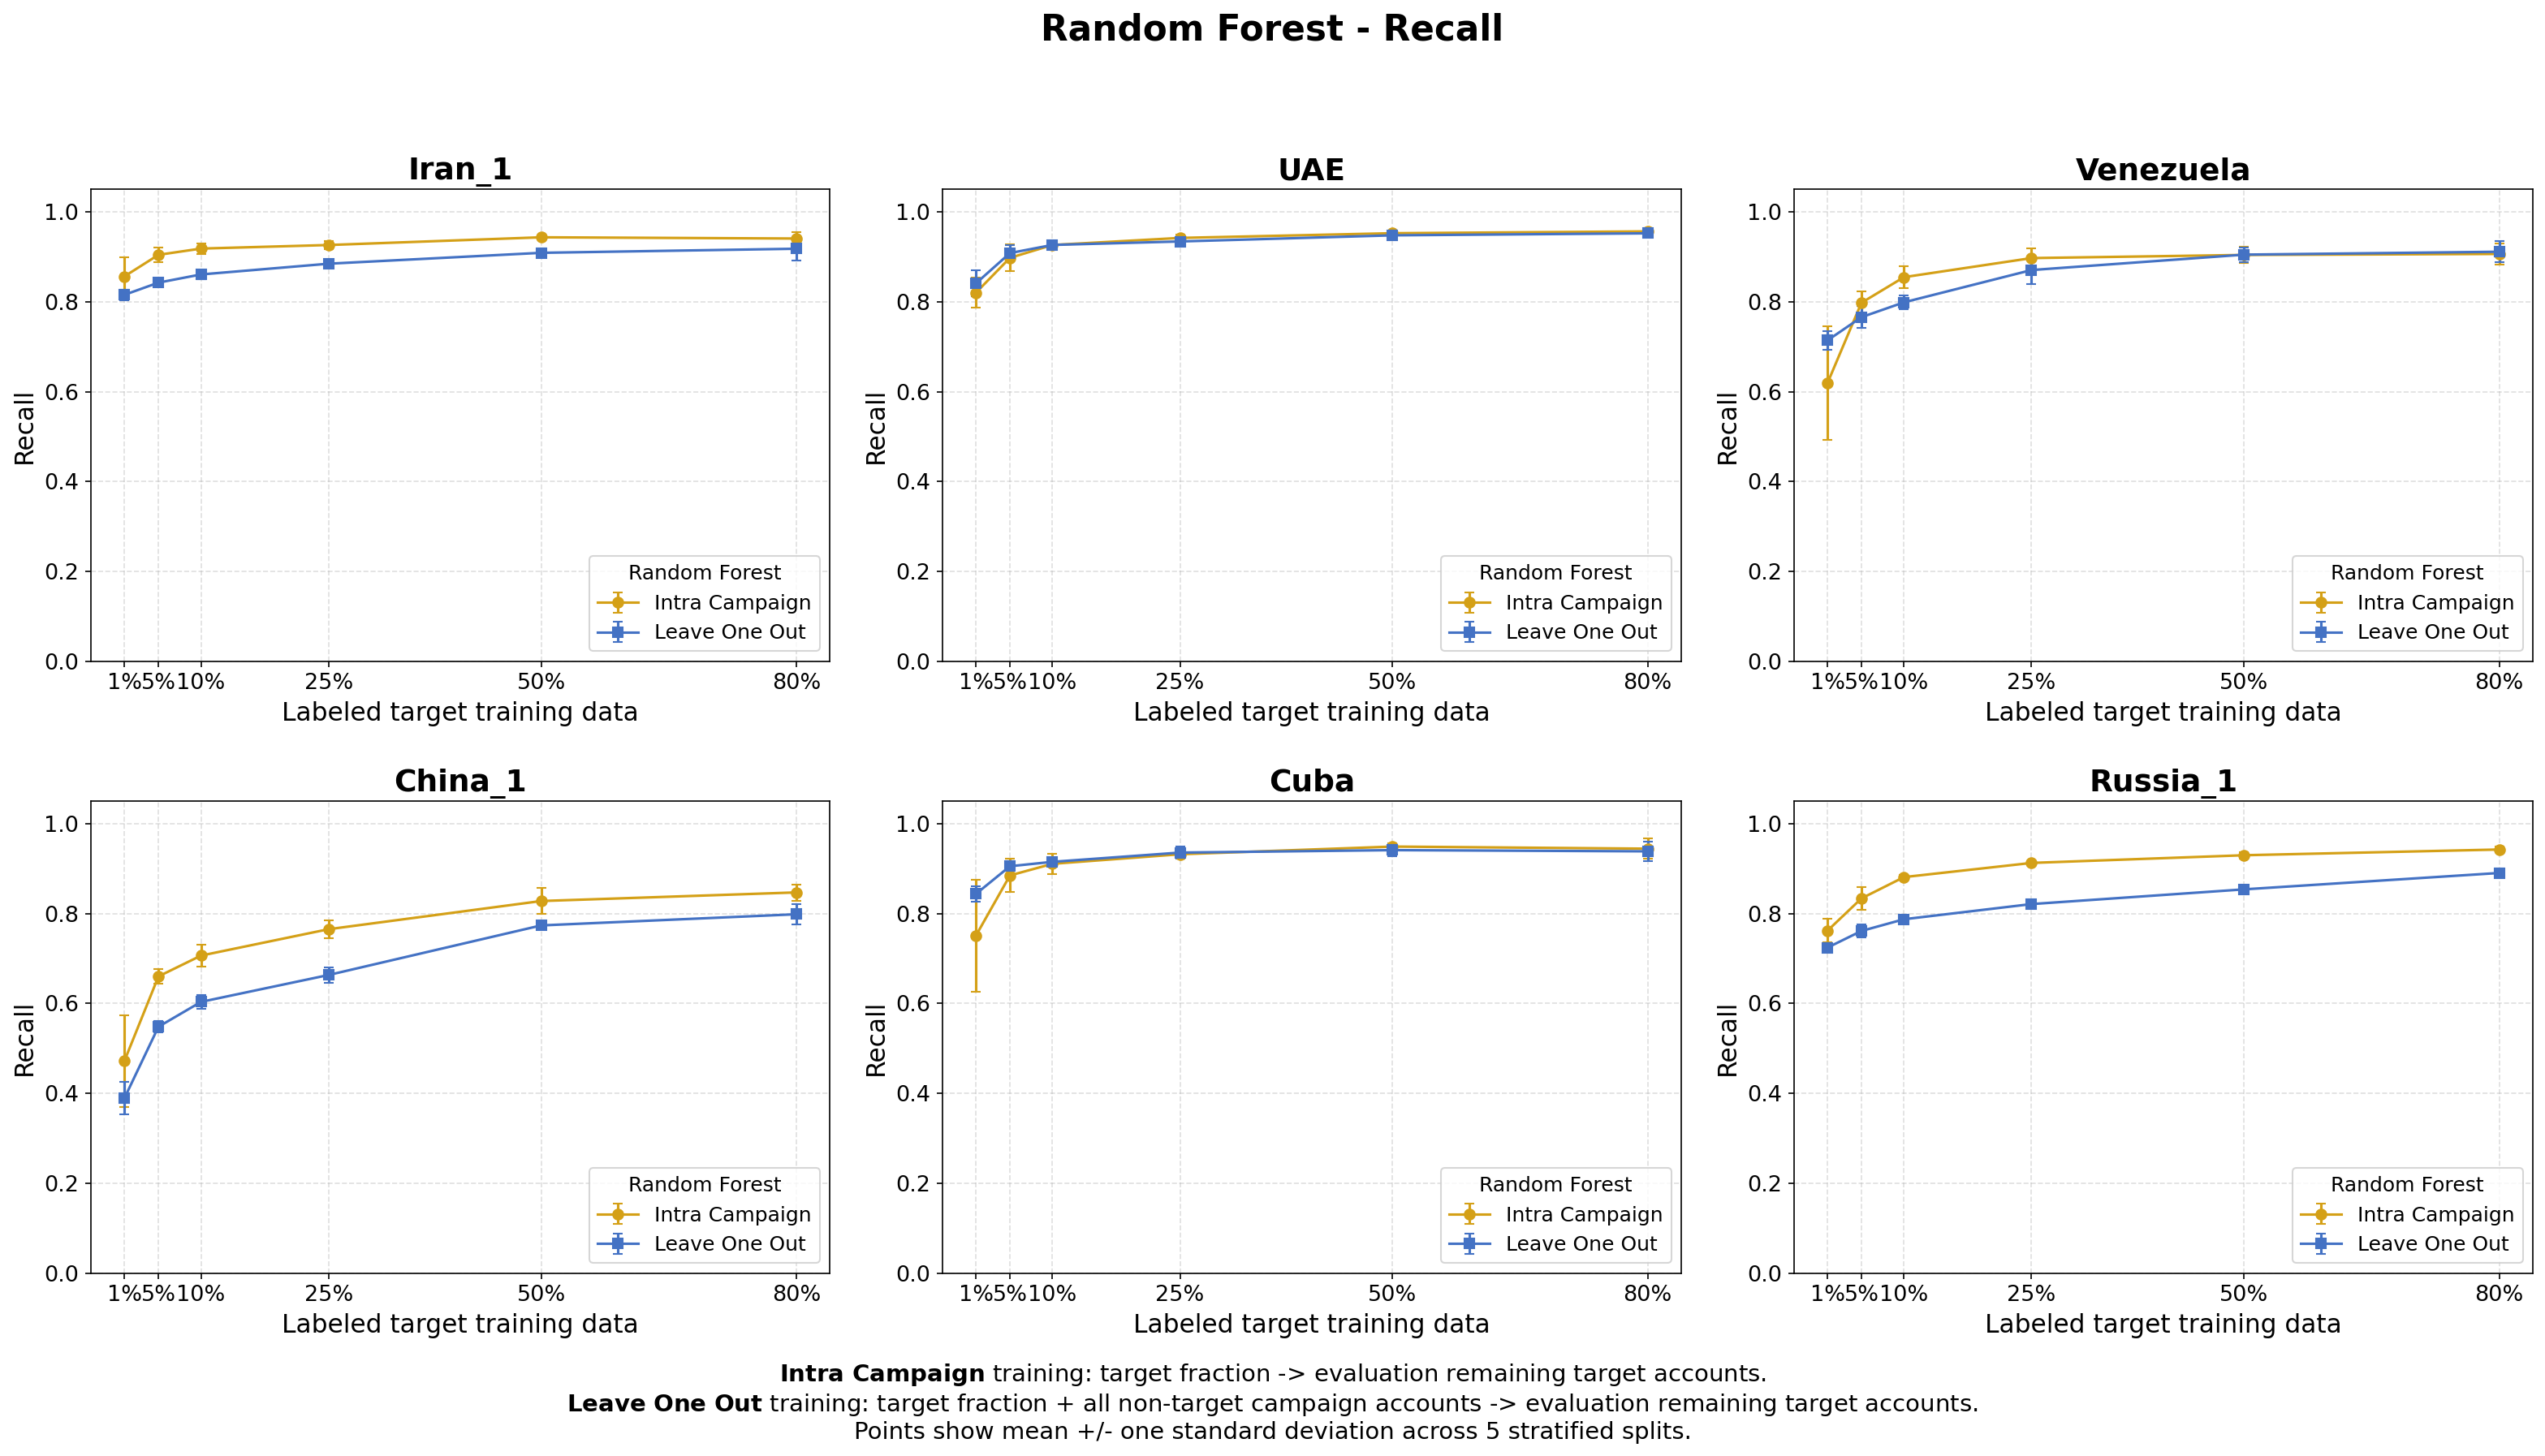

2026-08-18 12:53:01 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_strategy_comparison_precision.png


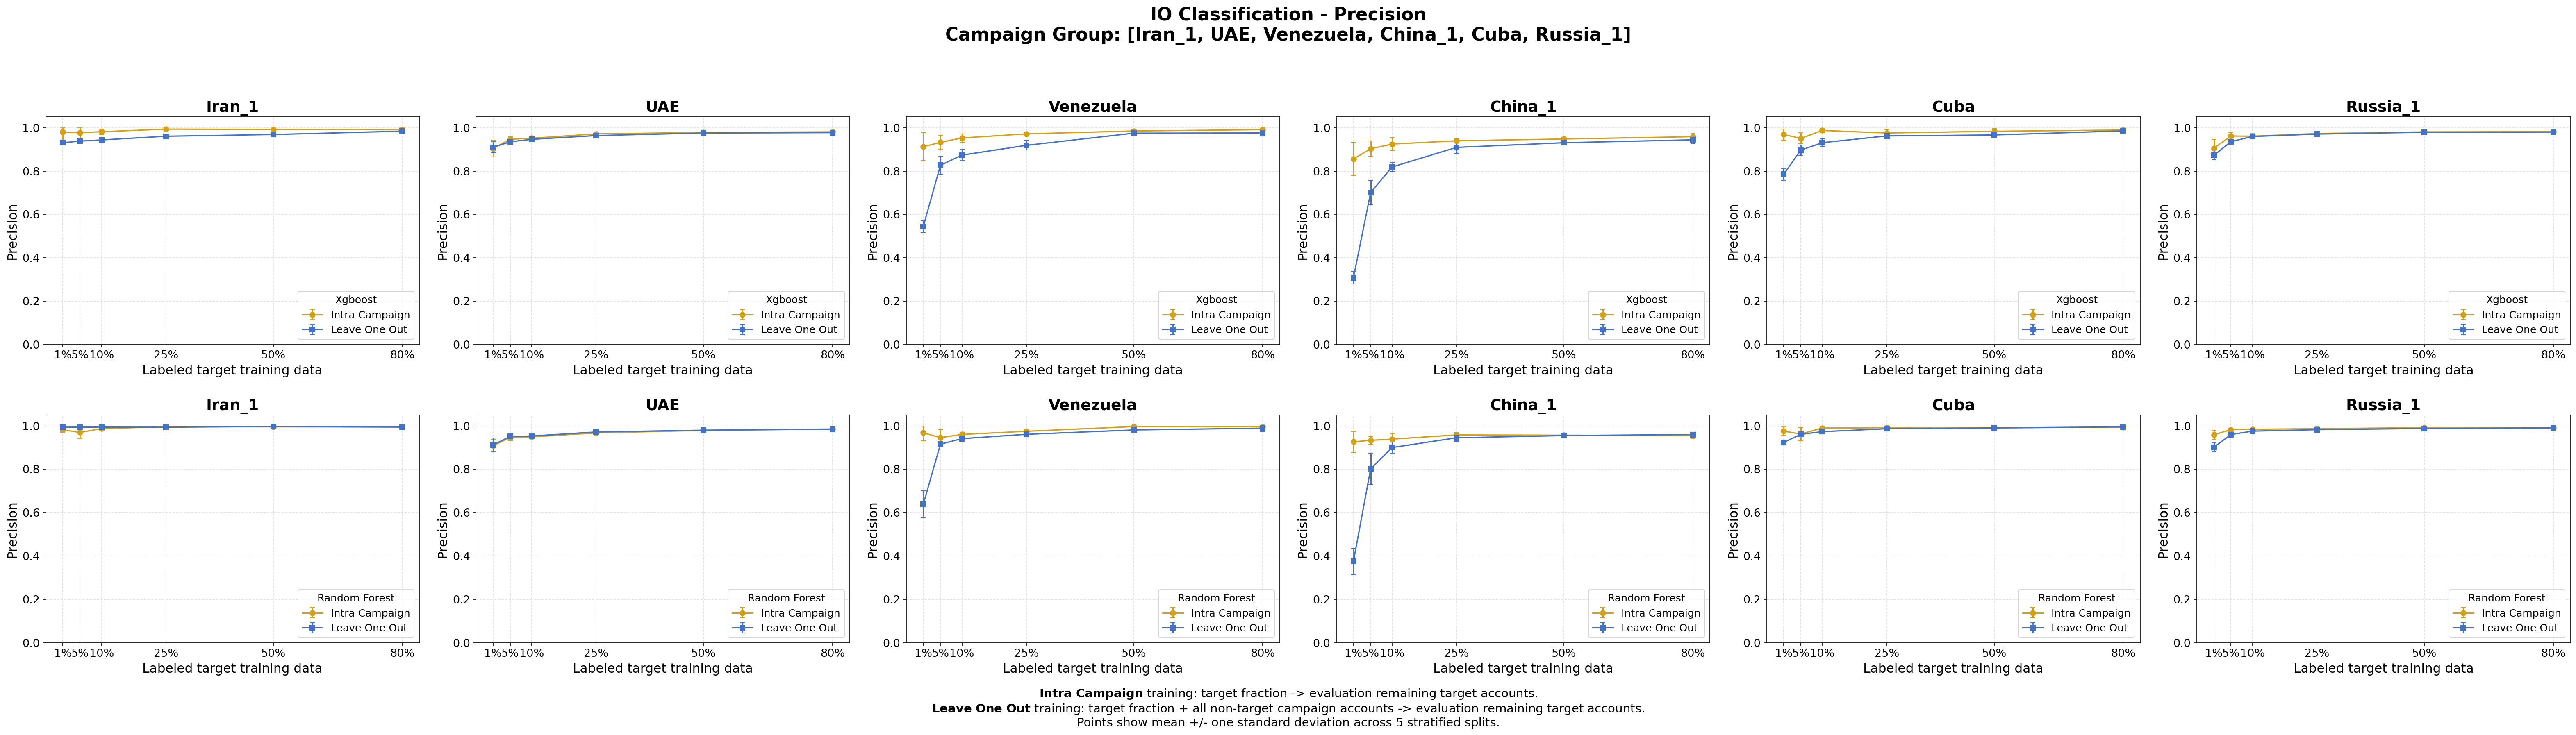

2026-08-18 12:53:05 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_precision_by_campaign.png


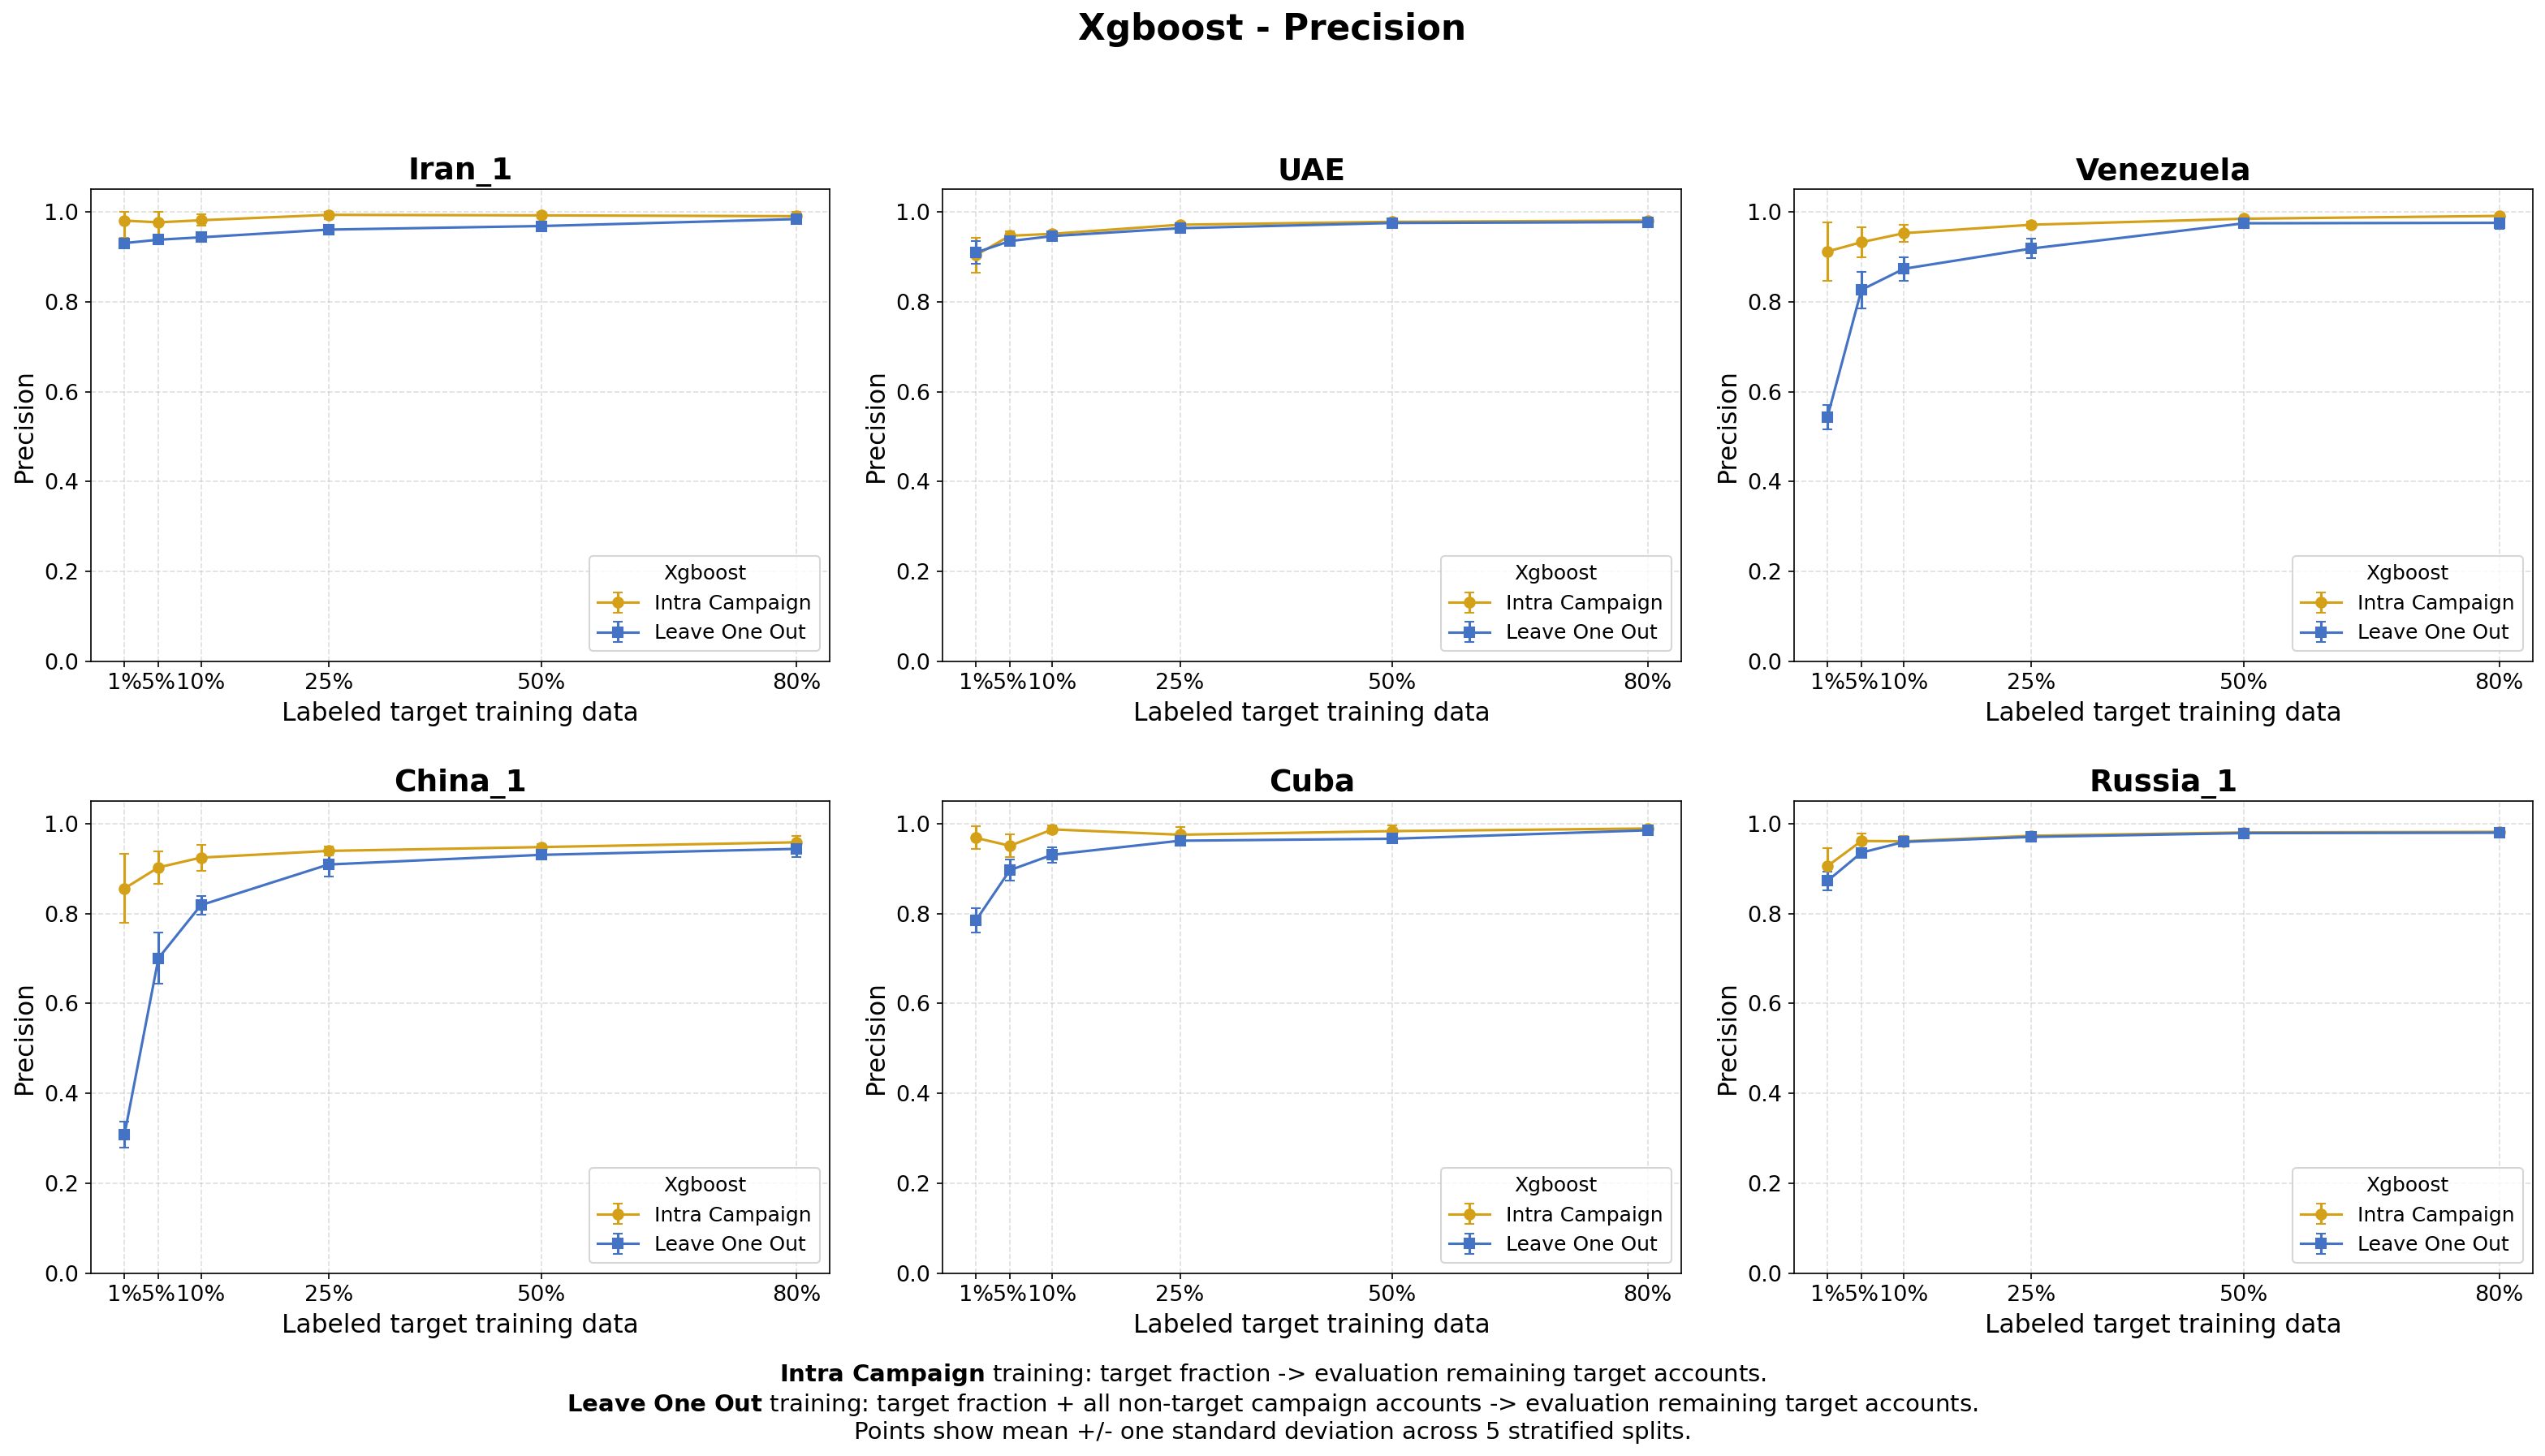

2026-08-18 12:53:09 | Saved plot to: ../results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_precision_by_campaign.png


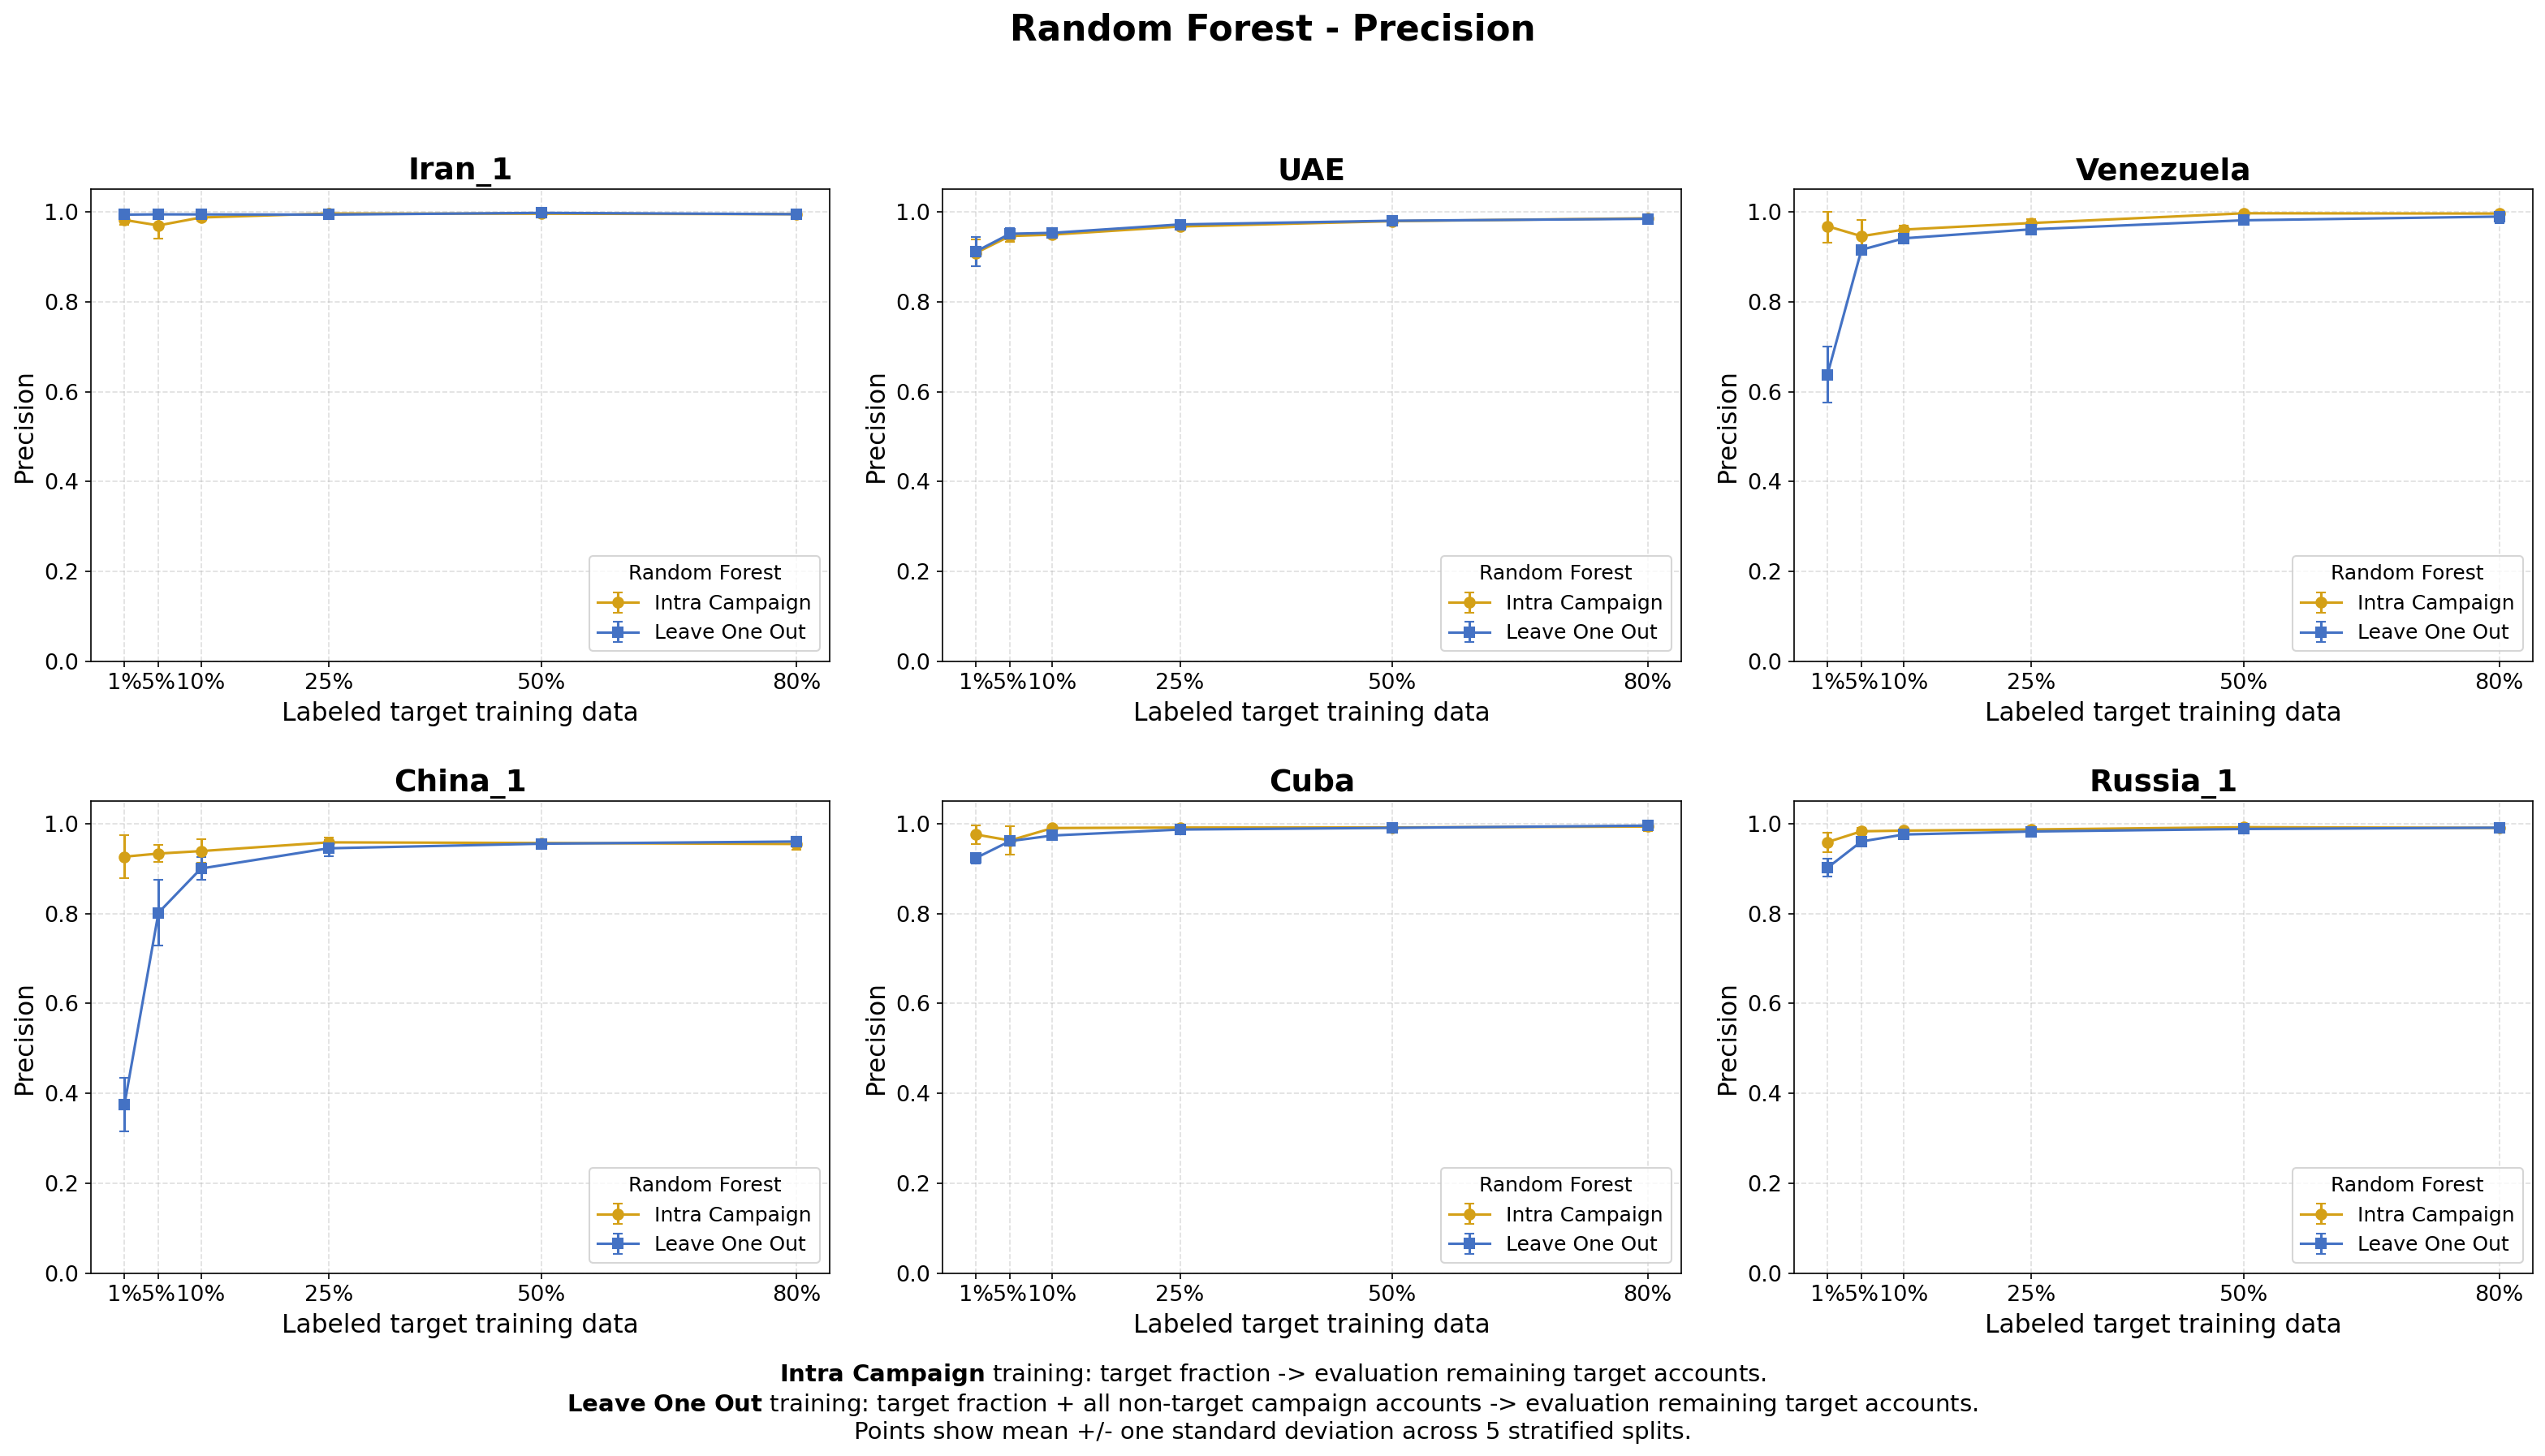

2026-08-18 12:53:10 | Pipeline completed.


In [24]:
if not results_df.empty:
    for metric in METRIC_COLUMNS:
        plot_campaign_performance(results_df, metric, output_path)
        for model_name in MODELS:
            plot_campaign_performance(
                results_df,
                metric,
                output_path,
                model_name=model_name,
            )

write_report("Pipeline completed.")